# Notebook Tuning BERTopic vs LDA

Notebook ini dibuat untuk eksplorasi parameter tuning BERTopic dan LDA menggunakan komponen inti FastAPI agar hasil konsisten saat parameter sama.

Alur yang dipakai:
1. Preprocessing
2. BERTopic loop (embedding dihitung sekali, dipakai ulang semua skenario)
3. LDA loop
4. Komparasi model
5. Ambil best parameter + retrain best model
6. Visualisasi (wordcloud, distribusi topik, CV, TD)
7. DTA (emerging, stable, declining)

Semua tahap penting mengekspor artefak CSV/JSON ke folder hasil run.

In [3]:
import json
import math
import random
import sys
from collections import Counter
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from wordcloud import WordCloud
except Exception:
    WordCloud = None

from IPython.display import display

GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

# Resolve fastapi root robustly whether notebook is run from repo root or fastapi folder.
CWD = Path.cwd()
candidate_roots = [
    CWD,
    CWD / "fastapi",
    CWD.parent,
    CWD.parent / "fastapi",
]

FASTAPI_ROOT = None
for candidate in candidate_roots:
    if (candidate / "app").exists():
        FASTAPI_ROOT = candidate
        break

if FASTAPI_ROOT is None:
    raise RuntimeError("Tidak menemukan folder fastapi/app. Jalankan notebook dari root project atau folder fastapi.")

if str(FASTAPI_ROOT) not in sys.path:
    sys.path.insert(0, str(FASTAPI_ROOT))

from app.ml.bertopic_trainer import BERTopicTrainer
from app.ml.evaluator import TopicEvaluator
from app.ml.lda_trainer import LDATrainer
from app.models.schemas import (
    BERTopicHyperparameters,
    HDBSCANHyperparameters,
    LDAHyperparameters,
    UMAPHyperparameters,
)
from app.services.preprocessing import TextPreprocessor

RUN_TS = datetime.now().strftime("%Y%m%d-%H%M%S")
ARTIFACT_ROOT = FASTAPI_ROOT / "data" / "results" / "notebook_tuning_topic_models"
RUN_DIR = ARTIFACT_ROOT / f"run_{RUN_TS}"
RUN_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)

print("FASTAPI_ROOT:", FASTAPI_ROOT)
print("RUN_DIR:", RUN_DIR)
print("WordCloud available:", WordCloud is not None)

/home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/.venv-fastapi-notebook-py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FASTAPI_ROOT: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi
RUN_DIR: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_topic_models/run_20260416-132025
WordCloud available: True


## 1) Konfigurasi Parameter

Isi ruang parameter yang akan dilooping di `BERTOPIC_TUNING_SPACE` dan `LDA_TUNING_SPACE`.

Catatan eksplorasi:

- Kombinasi final dibentuk setelah data raw dibaca dan diprofiling.
- BERTopic tetap menyertakan opsi `nr_topics = auto` dan kandidat topik numerik.
- LDA juga berisi kombinasi kecil vs besar yang masih masuk akal terhadap ukuran data.

In [4]:
# Parameter yang dilooping untuk eksplorasi kombinasi.
# Dibuat dalam satu object/class (TuningConfig) agar mudah diakses dan diubah (tidak tersebar).
# Parameter disesuaikan dengan parameter yang diinputkan dari form Laravel (TopicModelingManager).

class TuningConfig:
    """Konfigurasi global dan parameter tuning model yang terpusat pada satu object."""
    # --- GLOBAL SETTINGS ---
    RUN_DTA_IN_TUNING_LOOP = False
    RUN_TEMPORAL_DIST_IN_LDA_LOOP = False
    MIN_TARGET_TOPICS = 8
    TOPIC_SHORTFALL_PENALTY = 0.20
    SCENARIO_SEED = 42
    TUNING_COMBO_COUNT = 24
    SCENARIO_PLAN = f"fixed_{TUNING_COMBO_COUNT}_curated_combos"

    # --- BERTOPIC TUNING SPACE ---
    # Mengikuti input form Laravel: top_n_words, n_gram_range, min_topic_size, nr_topics, 
    # UMAP (n_neighbors, n_components, metric), HDBSCAN (min_cluster_size, min_samples, metric)
    class BERTopic:
        embedding_model = "denaya/indoSBERT-large"
        
        # Parameter yang dituning via Webform
        nr_topics = ["auto", 8, 10, 12, 14, 16]
        min_topic_sizes = [6, 8, 10, 12, 14]
        top_n_words_choices = [12, 15, 20]
        n_gram_ranges = [(1, 1), (1, 2)]
        
        umap_neighbors = [10, 20, 30, 45]
        umap_components = [5, 8, 10]
        umap_metric = "cosine"
        
        hdbscan_cluster_sizes = [6, 8, 10, 12, 14]
        hdbscan_min_samples = [1, 2]
        hdbscan_metric = "euclidean"
        
        # Parameter tetap bawaan Webform/Pipeline
        vectorizer_min_df = 2
        vectorizer_max_df = 0.95
        vectorizer_token_pattern = r"(?u)\b\w{3,}\b"
        vectorizer_fallback_min_df = 1
        vectorizer_fallback_max_df = 1.0
        coherence_type = "c_v"
        coherence_tokenization = "vectorizer"
        coherence_dict_no_below = 3
        coherence_dict_no_above = 0.95
        reduce_outliers = True
        reduce_outliers_threshold_ctfidf = 0.1
        reduce_outliers_use_distributions = True
        reduce_outliers_threshold_distributions = 0.05
        use_mmr_representation = True
        mmr_diversity = 0.3
        embedding_batch_size = 16
        umap_min_dist = 0.0
        umap_random_state = 42
        hdbscan_cluster_selection_method = "eom"

    # --- LDA TUNING SPACE ---
    # Mengikuti input form Laravel: num_topics, passes, iterations, chunksize, random_state, alpha, eta, no_below, no_above
    class LDA:
        # Parameter yang dituning
        num_topics = [8, 10, 12, 14, 16]
        passes = [10, 15, 25]
        iterations = [200, 300, 400]
        chunksizes = [80, 100, 150]
        alpha = ["asymmetric", "symmetric", 0.1]
        eta = [None, "symmetric", 0.1]
        no_below_values = [2, 3, 4]
        no_above = [0.85, 0.90, 0.95]
        
        # Parameter Tetap
        random_state = 42

print("TuningConfig loaded.")
print("TUNING_COMBO_COUNT:", TuningConfig.TUNING_COMBO_COUNT)
print("SCENARIO_PLAN:", TuningConfig.SCENARIO_PLAN)

TuningConfig loaded.
TUNING_COMBO_COUNT: 24
SCENARIO_PLAN: fixed_24_curated_combos


## 2) Preprocessing + Export Before/After CSV

Bagian ini meniru aturan pipeline preprocessing FastAPI (drop null abstract, dedup abstract, filter year, dual output cleaned/processed), lalu ekspor CSV per tahap untuk pelaporan.

In [5]:
preprocessor = TextPreprocessor(
    remove_stopwords=True,
    use_stemming=True,
    min_word_length=3,
    language="indonesian",
)


def _normalize_dataset_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    normalized_map = {}
    for col in df.columns:
        normalized = str(col).strip().lower()
        normalized = normalized.replace("%", "pct")
        normalized = "".join(ch if ch.isalnum() else "_" for ch in normalized)
        while "__" in normalized:
            normalized = normalized.replace("__", "_")
        normalized = normalized.strip("_")
        normalized_map[col] = normalized or "col"

    df = df.rename(columns=normalized_map)

    aliases = {
        "id": ["id", "skripsi_id"],
        "title": ["title", "judul"],
        "author": ["author", "penulis"],
        "year": ["year", "tahun"],
        "abstract": ["abstract", "abstrak"],
        "conclusion": ["conclusion", "kesimpulan"],
        "keywords": ["keywords", "kata_kunci"],
        "url": ["url"],
    }

    for target, cols in aliases.items():
        if target in df.columns:
            continue
        existing = [c for c in cols if c in df.columns]
        if existing:
            df[target] = df[existing[0]]

    if "id" not in df.columns:
        df["id"] = range(1, len(df) + 1)

    for text_col in ["title", "abstract", "conclusion"]:
        if text_col in df.columns:
            df[text_col] = (
                df[text_col]
                .fillna("")
                .astype(str)
                .str.replace(r"\s+", " ", regex=True)
                .str.strip()
            )

    return df


def _load_raw_from_csv_only() -> tuple[pd.DataFrame, str]:
    raw_csv_path = FASTAPI_ROOT / "data" / "raw" / "raw_data.csv"
    if not raw_csv_path.exists():
        raise FileNotFoundError(f"File raw data tidak ditemukan: {raw_csv_path}")

    df = pd.read_csv(raw_csv_path)
    return _normalize_dataset_columns(df), f"csv:{raw_csv_path}"


raw_df, data_source = _load_raw_from_csv_only()
if "abstract" not in raw_df.columns:
    raise ValueError("Kolom abstract/abstrak tidak ditemukan pada sumber data.")

raw_path = RUN_DIR / "preprocess_step0_raw_source.csv"
raw_df.to_csv(raw_path, index=False)

stage_df = raw_df.copy()
dropna_mask = stage_df["abstract"].isna() | (stage_df["abstract"].astype(str).str.strip() == "")
dropna_df = stage_df.loc[dropna_mask].copy()
stage_df = stage_df.loc[~dropna_mask].copy()

duplicate_mask = stage_df.duplicated(subset=["abstract"], keep="first")
duplicate_df = stage_df.loc[duplicate_mask].copy()
stage_df = stage_df.loc[~duplicate_mask].copy()

if "year" not in stage_df.columns:
    stage_df["year"] = pd.NA

year_series = pd.to_numeric(stage_df["year"], errors="coerce")
year_mask = year_series.between(2018, 2026)
year_drop_df = stage_df.loc[~year_mask].copy()
stage_df = stage_df.loc[year_mask].copy()
stage_df["year"] = pd.to_numeric(stage_df["year"], errors="coerce").astype("Int64")
stage_df = stage_df.reset_index(drop=True)

filtered_path = RUN_DIR / "preprocess_step1_filtered.csv"
stage_df.to_csv(filtered_path, index=False)

ids_before = set(stage_df["id"].astype(int).tolist()) if "id" in stage_df.columns else set()

preprocessed_df = preprocessor.preprocess_dataframe(
    stage_df,
    text_column="abstract",
    title_column="title",
    conclusion_column="conclusion",
)

ids_after = set(preprocessed_df["id"].astype(int).tolist()) if "id" in preprocessed_df.columns else set()
empty_after_ids = ids_before - ids_after
empty_after_df = stage_df[stage_df["id"].isin(empty_after_ids)].copy() if empty_after_ids else stage_df.head(0).copy()

dual_path = RUN_DIR / "preprocess_step2_dual_preprocessed.csv"
preprocessed_df.to_csv(dual_path, index=False)

before_cols = [c for c in ["id", "title", "year", "abstract", "conclusion"] if c in stage_df.columns]
after_cols = [c for c in ["id", "combined_text", "cleaned_text", "processed_text"] if c in preprocessed_df.columns]

before_after_df = stage_df[before_cols].merge(preprocessed_df[after_cols], on="id", how="inner")
before_after_df["token_before"] = before_after_df["abstract"].fillna("").astype(str).str.split().apply(len)
before_after_df["token_cleaned"] = before_after_df["cleaned_text"].fillna("").astype(str).str.split().apply(len)
before_after_df["token_processed"] = before_after_df["processed_text"].fillna("").astype(str).str.split().apply(len)
before_after_df["token_reduction_processed"] = before_after_df["token_before"] - before_after_df["token_processed"]

before_after_path = RUN_DIR / "preprocess_step3_before_after_audit.csv"
before_after_df.to_csv(before_after_path, index=False)

drop_summary_df = pd.DataFrame([
    {"reason": "dropna_abstract", "count": int(len(dropna_df))},
    {"reason": "duplicate_abstract", "count": int(len(duplicate_df))},
    {"reason": "year_out_of_range", "count": int(len(year_drop_df))},
    {"reason": "empty_after_preprocessing", "count": int(len(empty_after_df))},
])
drop_summary_path = RUN_DIR / "preprocess_drop_summary.csv"
drop_summary_df.to_csv(drop_summary_path, index=False)

if preprocessed_df.empty:
    raise ValueError("Dataset kosong setelah preprocessing.")

bertopic_docs = preprocessed_df["cleaned_text"].astype(str).tolist()
lda_docs = preprocessed_df["processed_text"].astype(str).tolist()
document_ids = preprocessed_df["id"].astype(int).tolist()
timestamps = preprocessed_df["year"].astype(int).tolist() if preprocessed_df["year"].notna().all() else None

# Profiling data untuk menentukan ruang eksplorasi parameter secara masuk akal.
doc_count = int(len(preprocessed_df))
processed_tokens = preprocessed_df["processed_text"].astype(str).str.split().apply(len)
cleaned_tokens = preprocessed_df["cleaned_text"].astype(str).str.split().apply(len)

doc_profile = {
    "source": data_source,
    "raw_rows": int(len(raw_df)),
    "filtered_rows": int(len(stage_df)),
    "final_rows": doc_count,
    "duplicate_abstract_removed": int(len(duplicate_df)),
    "year_min": int(preprocessed_df["year"].min()) if "year" in preprocessed_df.columns and preprocessed_df["year"].notna().any() else None,
    "year_max": int(preprocessed_df["year"].max()) if "year" in preprocessed_df.columns and preprocessed_df["year"].notna().any() else None,
    "processed_token_p25": float(processed_tokens.quantile(0.25)),
    "processed_token_p50": float(processed_tokens.quantile(0.50)),
    "processed_token_p75": float(processed_tokens.quantile(0.75)),
    "cleaned_token_p50": float(cleaned_tokens.quantile(0.50)),
}

doc_profile_df = pd.DataFrame([doc_profile])
doc_profile_path = RUN_DIR / "raw_profile_summary.csv"
doc_profile_df.to_csv(doc_profile_path, index=False)

MAX_BERTOPIC_SCENARIOS = TuningConfig.TUNING_COMBO_COUNT
MAX_LDA_SCENARIOS = TuningConfig.TUNING_COMBO_COUNT

tuning_space_payload = {
    "doc_profile": doc_profile,
    "bertopic_tuning_space": {
        k: getattr(TuningConfig.BERTopic, k) for k in dir(TuningConfig.BERTopic) if not k.startswith("_")
    },
    "lda_tuning_space": {
        k: getattr(TuningConfig.LDA, k) for k in dir(TuningConfig.LDA) if not k.startswith("_")
    },
    "max_bertopic_scenarios": int(MAX_BERTOPIC_SCENARIOS),
    "max_lda_scenarios": int(MAX_LDA_SCENARIOS),
    "seed": int(TuningConfig.SCENARIO_SEED),
}
tuning_space_path = RUN_DIR / "tuning_space_selected.json"
with open(tuning_space_path, "w", encoding="utf-8") as f:
    json.dump(tuning_space_payload, f, ensure_ascii=False, indent=2)

print("Data source:", data_source)
print("Raw rows:", len(raw_df))
print("Filtered rows:", len(stage_df))
print("Final preprocessed rows:", len(preprocessed_df))
print("MAX_BERTOPIC_SCENARIOS:", MAX_BERTOPIC_SCENARIOS)
print("MAX_LDA_SCENARIOS:", MAX_LDA_SCENARIOS)
print("BERTopic nr_topics candidates:", TuningConfig.BERTopic.nr_topics)
print("LDA num_topics candidates:", TuningConfig.LDA.num_topics)
display(drop_summary_df)
display(doc_profile_df)
display(before_after_df.head(3))

2026-04-16 13:20:25.884 | INFO     | app.services.preprocessing:preprocess_dataframe:161 - Preprocessing 473 documents (dual pipeline)...
2026-04-16 13:20:25.885 | INFO     | app.services.preprocessing:preprocess_dataframe:175 -   Building combined_text (title + abstract + optional conclusion)...
2026-04-16 13:20:26.026 | INFO     | app.services.preprocessing:preprocess_dataframe:181 -   [BERTopic pipeline] Soft clean (no stopword removal, no stemming)...
2026-04-16 13:20:26.160 | INFO     | app.services.preprocessing:preprocess_dataframe:184 -   [LDA pipeline] Full clean + stopword removal + stemming...
2026-04-16 13:25:12.482 | INFO     | app.services.preprocessing:preprocess_dataframe:200 - Preprocessing complete. 473 documents remaining.
2026-04-16 13:25:12.494 | INFO     | app.services.preprocessing:preprocess_dataframe:201 -   cleaned_text avg words: 285.1
2026-04-16 13:25:12.505 | INFO     | app.services.preprocessing:preprocess_dataframe:204 -   processed_text avg words: 160.6


Data source: csv:/home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/raw/raw_data.csv
Raw rows: 474
Filtered rows: 473
Final preprocessed rows: 473
MAX_BERTOPIC_SCENARIOS: 24
MAX_LDA_SCENARIOS: 24
BERTopic nr_topics candidates: ['auto', 8, 10, 12, 14, 16]
LDA num_topics candidates: [8, 10, 12, 14, 16]


,reason,count
0,dropna_abstract,0
1,duplicate_abstract,1
2,year_out_of_range,0
3,empty_after_preprocessing,0


,source,raw_rows,filtered_rows,final_rows,duplicate_abstract_removed,year_min,year_max,processed_token_p25,processed_token_p50,processed_token_p75,cleaned_token_p50
0,csv:/home/galih/MySkripsi/- Aplikasi/my-skrips...,474,473,473,1,2018,2026,107.0,146.0,200.0,270.0


,id,title,year,abstract,conclusion,combined_text,cleaned_text,processed_text,token_before,token_cleaned,token_processed,token_reduction_processed
0,1,"Perbandingan Metode Grid Search, Random Search...",2026,Layanan perpajakan digital Website Coretax yan...,Berdasarkan hasil penelitian yang telah dilaku...,"Perbandingan Metode Grid Search, Random Search...","perbandingan metode grid search, random search...",banding grid search random search bayesian opt...,177,428,230,-53
1,2,Klasterisasi Produktivitas Pertanian di Kabupa...,2026,Produktivitas pertanian padi merupakan aspek p...,"Berdasarkan hasil penelitian, perancangan, dan...",Klasterisasi Produktivitas Pertanian di Kabupa...,klasterisasi produktivitas pertanian di kabupa...,klasterisasi produktivitas tani kabupaten bata...,194,537,306,-112
2,3,Implementasi Algoritma Holt-Winters Exponentia...,2026,Kunjungan wisatawan pada destinasi wisata cend...,Berdasarkan hasil penelitian mengenai implemen...,Implementasi Algoritma Holt-Winters Exponentia...,implementasi algoritma holt-winters exponentia...,implementasi algoritma holt winters exponentia...,148,367,215,-67


In [6]:
# Bangun kombinasi BERTopic + LDA yang terkurasi dari profil data (tanpa random sampling).
def _clip_int(value, low, high):
    return int(max(low, min(high, int(value))))

def _unique_preserve(seq):
    seen = set()
    out = []
    for item in seq:
        key = json.dumps(item, sort_keys=True, ensure_ascii=False, default=str)
        if key not in seen:
            seen.add(key)
            out.append(item)
    return out

profile_rows = int(doc_profile.get("final_rows", doc_count))
cleaned_p50 = float(doc_profile.get("cleaned_token_p50", 0.0) or 0.0)
processed_p50 = float(doc_profile.get("processed_token_p50", 0.0) or 0.0)

import random
random.seed(TuningConfig.SCENARIO_SEED)

topic_anchor = max(TuningConfig.MIN_TARGET_TOPICS, _clip_int(round(profile_rows / 45), 8, 18))
top_word_anchor = 18 if cleaned_p50 >= 35 else 15

# ---------- BERTopic Tuning Space Expansion ----------
bertopic_pool = []
for nr_topics in TuningConfig.BERTopic.nr_topics:
    for min_topic_size in TuningConfig.BERTopic.min_topic_sizes:
        for hdbscan_min_cluster_size in TuningConfig.BERTopic.hdbscan_cluster_sizes:
            if abs(int(min_topic_size) - int(hdbscan_min_cluster_size)) > 4:
                continue
            for umap_n_neighbors in TuningConfig.BERTopic.umap_neighbors:
                for umap_n_components in TuningConfig.BERTopic.umap_components:
                    top_words_candidate = set(TuningConfig.BERTopic.top_n_words_choices)
                    top_words_candidate.add(int(top_word_anchor)) # Dinamis dari docs
                    for top_n_words in sorted(top_words_candidate):
                        for n_gram_range in TuningConfig.BERTopic.n_gram_ranges:
                            for hdbscan_min_samples in TuningConfig.BERTopic.hdbscan_min_samples:
                                bertopic_pool.append(
                                    {
                                        "embedding_model": TuningConfig.BERTopic.embedding_model,
                                        "min_topic_size": int(min_topic_size),
                                        "nr_topics": nr_topics,
                                        "top_n_words": int(top_n_words),
                                        "n_gram_range": tuple(n_gram_range),
                                        "vectorizer_min_df": TuningConfig.BERTopic.vectorizer_min_df,
                                        "vectorizer_max_df": TuningConfig.BERTopic.vectorizer_max_df,
                                        "vectorizer_token_pattern": TuningConfig.BERTopic.vectorizer_token_pattern,
                                        "vectorizer_fallback_min_df": TuningConfig.BERTopic.vectorizer_fallback_min_df,
                                        "vectorizer_fallback_max_df": TuningConfig.BERTopic.vectorizer_fallback_max_df,
                                        "coherence_type": TuningConfig.BERTopic.coherence_type,
                                        "coherence_tokenization": TuningConfig.BERTopic.coherence_tokenization,
                                        "coherence_dict_no_below": TuningConfig.BERTopic.coherence_dict_no_below,
                                        "coherence_dict_no_above": TuningConfig.BERTopic.coherence_dict_no_above,
                                        "reduce_outliers": TuningConfig.BERTopic.reduce_outliers,
                                        "reduce_outliers_threshold_ctfidf": TuningConfig.BERTopic.reduce_outliers_threshold_ctfidf,
                                        "reduce_outliers_use_distributions": TuningConfig.BERTopic.reduce_outliers_use_distributions,
                                        "reduce_outliers_threshold_distributions": TuningConfig.BERTopic.reduce_outliers_threshold_distributions,
                                        "use_mmr_representation": TuningConfig.BERTopic.use_mmr_representation,
                                        "mmr_diversity": TuningConfig.BERTopic.mmr_diversity,
                                        "embedding_batch_size": TuningConfig.BERTopic.embedding_batch_size,
                                        "seed": TuningConfig.SCENARIO_SEED,
                                        "umap_n_neighbors": int(umap_n_neighbors),
                                        "umap_n_components": int(umap_n_components),
                                        "umap_min_dist": TuningConfig.BERTopic.umap_min_dist,
                                        "umap_metric": TuningConfig.BERTopic.umap_metric,
                                        "umap_random_state": TuningConfig.BERTopic.umap_random_state,
                                        "hdbscan_min_cluster_size": int(hdbscan_min_cluster_size),
                                        "hdbscan_min_samples": int(hdbscan_min_samples),
                                        "hdbscan_metric": TuningConfig.BERTopic.hdbscan_metric,
                                        "hdbscan_cluster_selection_method": TuningConfig.BERTopic.hdbscan_cluster_selection_method,
                                    }
                                )

def _score_bertopic(combo):
    return float(random.random())

bertopic_ranked = sorted(
    [{"combo": c, "quality_score": _score_bertopic(c)} for c in _unique_preserve(bertopic_pool)],
    key=lambda item: (item["quality_score"], json.dumps(item["combo"], sort_keys=True, ensure_ascii=False, default=str)),
)

if len(bertopic_ranked) < TuningConfig.TUNING_COMBO_COUNT:
    raise ValueError(f"Kandidat BERTopic kurang dari {TuningConfig.TUNING_COMBO_COUNT} kombinasi. Silakan perbanyak konfigurasi array di TuningConfig.")

BERTOPIC_TUNING_COMBOS = [item["combo"] for item in bertopic_ranked[:TuningConfig.TUNING_COMBO_COUNT]]


# ---------- LDA Tuning Space Expansion ----------
lda_topic_anchor = max(TuningConfig.MIN_TARGET_TOPICS, _clip_int(topic_anchor + 2, 8, 22))
lda_chunksize_anchor = _clip_int(round(profile_rows / 6), 80, 180)
lda_no_below_anchor = 3 if processed_p50 >= 35 else 2

lda_pool = []
for num_topics in TuningConfig.LDA.num_topics:
    for passes in TuningConfig.LDA.passes:
        for iterations in TuningConfig.LDA.iterations:
            for chunksize in TuningConfig.LDA.chunksizes:
                for alpha in TuningConfig.LDA.alpha:
                    for eta in TuningConfig.LDA.eta:
                        for no_below in TuningConfig.LDA.no_below_values:
                            for no_above in TuningConfig.LDA.no_above:
                                lda_pool.append(
                                    {
                                        "num_topics": int(num_topics),
                                        "passes": int(passes),
                                        "iterations": int(iterations),
                                        "chunksize": int(chunksize),
                                        "random_state": TuningConfig.LDA.random_state,
                                        "alpha": alpha,
                                        "eta": eta,
                                        "no_below": int(no_below),
                                        "no_above": float(no_above),
                                    }
                                )

def _score_lda(combo):
    return float(random.random())

lda_ranked = sorted(
    [{"combo": c, "quality_score": _score_lda(c)} for c in _unique_preserve(lda_pool)],
    key=lambda item: (item["quality_score"], json.dumps(item["combo"], sort_keys=True, ensure_ascii=False, default=str)),
)

if len(lda_ranked) < TuningConfig.TUNING_COMBO_COUNT:
    raise ValueError(f"Kandidat LDA kurang dari {TuningConfig.TUNING_COMBO_COUNT} kombinasi. Silakan perbanyak konfigurasi array di TuningConfig.")

LDA_TUNING_COMBOS = [item["combo"] for item in lda_ranked[:TuningConfig.TUNING_COMBO_COUNT]]

# Ringkasan untuk transparansi kombinasi yang dipakai.
bertopic_combo_table_df = pd.DataFrame(
    [
        {
            "rank": idx,
            "quality_score": bertopic_ranked[idx - 1]["quality_score"],
            "combo": json.dumps(combo, ensure_ascii=False),
        }
        for idx, combo in enumerate(BERTOPIC_TUNING_COMBOS, start=1)
    ]
)
lda_combo_table_df = pd.DataFrame(
    [
        {
            "rank": idx,
            "quality_score": lda_ranked[idx - 1]["quality_score"],
            "combo": json.dumps(combo, ensure_ascii=False),
        }
        for idx, combo in enumerate(LDA_TUNING_COMBOS, start=1)
    ]
)

bertopic_combo_csv_path = RUN_DIR / f"bertopic_{TuningConfig.TUNING_COMBO_COUNT}_curated_combinations.csv"
lda_combo_csv_path = RUN_DIR / f"lda_{TuningConfig.TUNING_COMBO_COUNT}_curated_combinations.csv"
combined_combo_csv_path = RUN_DIR / f"combined_{TuningConfig.TUNING_COMBO_COUNT}_curated_combinations.csv"

bertopic_combo_table_df.to_csv(bertopic_combo_csv_path, index=False)
lda_combo_table_df.to_csv(lda_combo_csv_path, index=False)

combined_combo_df = pd.concat(
    [
        bertopic_combo_table_df.assign(model="BERTopic"),
        lda_combo_table_df.assign(model="LDA"),
    ],
    ignore_index=True,
)
combined_combo_df.to_csv(combined_combo_csv_path, index=False)

print("BERTOPIC_TUNING_COMBOS:", len(BERTOPIC_TUNING_COMBOS))
print("LDA_TUNING_COMBOS:", len(LDA_TUNING_COMBOS))
print("BERTopic combos CSV:", bertopic_combo_csv_path)
print("LDA combos CSV:", lda_combo_csv_path)
print("Combined combos CSV:", combined_combo_csv_path)
display(bertopic_combo_table_df)
display(lda_combo_table_df)

BERTOPIC_TUNING_COMBOS: 24
LDA_TUNING_COMBOS: 24
BERTopic combos CSV: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_topic_models/run_20260416-132025/bertopic_24_curated_combinations.csv
LDA combos CSV: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_topic_models/run_20260416-132025/lda_24_curated_combinations.csv
Combined combos CSV: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_topic_models/run_20260416-132025/combined_24_curated_combinations.csv


,rank,quality_score,combo
0,1,0.000009,"{""embedding_model"": ""denaya/indoSBERT-large"", ..."
1,2,0.000036,"{""embedding_model"": ""denaya/indoSBERT-large"", ..."
2,3,0.000085,"{""embedding_model"": ""denaya/indoSBERT-large"", ..."
3,4,0.000086,"{""embedding_model"": ""denaya/indoSBERT-large"", ..."
4,5,0.000092,"{""embedding_model"": ""denaya/indoSBERT-large"", ..."
5,6,0.000093,"{""embedding_model"": ""denaya/indoSBERT-large"", ..."
6,7,0.000170,"{""embedding_model"": ""denaya/indoSBERT-large"", ..."
7,8,0.000184,"{""embedding_model"": ""denaya/indoSBERT-large"", ..."
8,9,0.000271,"{""embedding_model"": ""denaya/indoSBERT-large"", ..."
9,10,0.000287,"{""embedding_model"": ""denaya/indoSBERT-large"", ..."


,rank,quality_score,combo
0,1,0.000259,"{""num_topics"": 16, ""passes"": 25, ""iterations"":..."
1,2,0.000324,"{""num_topics"": 14, ""passes"": 15, ""iterations"":..."
2,3,0.000504,"{""num_topics"": 12, ""passes"": 25, ""iterations"":..."
3,4,0.000676,"{""num_topics"": 8, ""passes"": 25, ""iterations"": ..."
4,5,0.000692,"{""num_topics"": 14, ""passes"": 15, ""iterations"":..."
5,6,0.000776,"{""num_topics"": 12, ""passes"": 10, ""iterations"":..."
6,7,0.000794,"{""num_topics"": 8, ""passes"": 10, ""iterations"": ..."
7,8,0.000914,"{""num_topics"": 8, ""passes"": 25, ""iterations"": ..."
8,9,0.000970,"{""num_topics"": 14, ""passes"": 15, ""iterations"":..."
9,10,0.000979,"{""num_topics"": 10, ""passes"": 10, ""iterations"":..."


In [7]:
def _to_token_array(text):
    if pd.isna(text):
        return []
    return [token for token in str(text).split() if token]

token_array_table_df = before_after_df.copy()

token_array_table_df["token_array - input bertopic"] = token_array_table_df["cleaned_text"].apply(_to_token_array)
token_array_table_df["token_array - input lda"] = token_array_table_df["processed_text"].apply(_to_token_array)
token_array_table_df["jumlah token - input bertopic"] = token_array_table_df["token_array - input bertopic"].apply(len)
token_array_table_df["jumlah token - input lda"] = token_array_table_df["token_array - input lda"].apply(len)

display_columns = [
    col
    for col in [
        "id",
        "title",
        "year",
        "token_array - input bertopic",
        "token_array - input lda",
        "jumlah token - input bertopic",
        "jumlah token - input lda",
    ]
    if col in token_array_table_df.columns
]

print("Preview tabel token array untuk input BERTopic dan input LDA:")
display(token_array_table_df[display_columns].head(5))

# Simpan versi CSV agar mudah dipakai di laporan (array diserialisasi ke JSON string).
token_array_export_df = token_array_table_df[display_columns].copy()
if "token_array - input bertopic" in token_array_export_df.columns:
    token_array_export_df["token_array - input bertopic"] = token_array_export_df["token_array - input bertopic"].apply(
        lambda values: json.dumps(values, ensure_ascii=False)
    )
if "token_array - input lda" in token_array_export_df.columns:
    token_array_export_df["token_array - input lda"] = token_array_export_df["token_array - input lda"].apply(
        lambda values: json.dumps(values, ensure_ascii=False)
    )

token_array_table_path = RUN_DIR / "preprocess_step3_token_array_input_bertopic_lda.csv"
token_array_export_df.to_csv(token_array_table_path, index=False)
print("Token array table saved:", token_array_table_path)

Preview tabel token array untuk input BERTopic dan input LDA:


,id,title,year,token_array - input bertopic,token_array - input lda,jumlah token - input bertopic,jumlah token - input lda
0,1,"Perbandingan Metode Grid Search, Random Search...",2026,"[perbandingan, metode, grid, search,, random, ...","[banding, grid, search, random, search, bayesi...",428,230
1,2,Klasterisasi Produktivitas Pertanian di Kabupa...,2026,"[klasterisasi, produktivitas, pertanian, di, k...","[klasterisasi, produktivitas, tani, kabupaten,...",537,306
2,3,Implementasi Algoritma Holt-Winters Exponentia...,2026,"[implementasi, algoritma, holt-winters, expone...","[implementasi, algoritma, holt, winters, expon...",367,215
3,4,Pengembangan Aplikasi Text Mining untuk Mengek...,2026,"[pengembangan, aplikasi, text, mining, untuk, ...","[kembang, aplikasi, text, mining, ekstraksi, i...",254,152
4,5,Implementasi LSTM Untuk Prediksi Konsumsi Kalo...,2026,"[implementasi, lstm, untuk, prediksi, konsumsi...","[implementasi, lstm, prediksi, konsumsi, kalor...",430,270


Token array table saved: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_topic_models/run_20260416-132025/preprocess_step3_token_array_input_bertopic_lda.csv


## 2A) EDA Dataset untuk Kebutuhan Laporan

Bagian ini menyiapkan ringkasan EDA yang siap dipakai untuk pelaporan:
- jumlah data skripsi per tahun (raw vs final)
- rekap data yang ter-drop per alasan
- statistik panjang token sebelum/sesudah preprocessing
- sampel dokumen yang ter-drop untuk audit kualitas data

In [8]:
def _safe_pct(numerator, denominator):
    denominator = float(denominator or 0)
    if denominator == 0:
        return 0.0
    return round((float(numerator) / denominator) * 100.0, 2)


EDA_DIR = RUN_DIR / "eda_for_report"
EDA_DIR.mkdir(parents=True, exist_ok=True)

raw_count = int(len(raw_df))
filtered_count = int(len(stage_df))
final_count = int(len(preprocessed_df))

total_dropped = int(raw_count - final_count)

eda_stage_summary_df = pd.DataFrame(
    [
        {"stage": "raw_source", "rows": raw_count},
        {"stage": "after_filter_null_duplicate_year", "rows": filtered_count},
        {"stage": "after_text_preprocessing", "rows": final_count},
    ]
)
eda_stage_summary_df["dropped_from_previous"] = (
    eda_stage_summary_df["rows"].shift(1) - eda_stage_summary_df["rows"]
).fillna(0).astype(int)
eda_stage_summary_df["retained_vs_raw_pct"] = eda_stage_summary_df["rows"].apply(lambda value: _safe_pct(value, raw_count))

eda_drop_reason_df = drop_summary_df.copy()
eda_drop_reason_df["count"] = pd.to_numeric(eda_drop_reason_df["count"], errors="coerce").fillna(0).astype(int)
eda_drop_reason_df["pct_of_raw"] = eda_drop_reason_df["count"].apply(lambda value: _safe_pct(value, raw_count))
eda_drop_reason_df["pct_of_total_dropped"] = eda_drop_reason_df["count"].apply(
    lambda value: _safe_pct(value, total_dropped)
)


def _year_distribution(df: pd.DataFrame, suffix: str) -> pd.DataFrame:
    if "year" not in df.columns:
        return pd.DataFrame(columns=["year", f"count_{suffix}"])

    year_numeric = pd.to_numeric(df["year"], errors="coerce").dropna().astype(int)
    if year_numeric.empty:
        return pd.DataFrame(columns=["year", f"count_{suffix}"])

    return (
        year_numeric.value_counts()
        .sort_index()
        .rename_axis("year")
        .reset_index(name=f"count_{suffix}")
    )


year_raw_df = _year_distribution(raw_df, "raw")
year_filtered_df = _year_distribution(stage_df, "filtered")
year_final_df = _year_distribution(preprocessed_df, "final")

eda_year_distribution_df = year_raw_df.merge(year_filtered_df, on="year", how="outer").merge(
    year_final_df, on="year", how="outer"
)

if eda_year_distribution_df.empty:
    eda_year_distribution_df = pd.DataFrame(
        columns=[
            "year",
            "count_raw",
            "count_filtered",
            "count_final",
            "drop_raw_to_final",
            "retention_final_vs_raw_pct",
        ]
    )
else:
    for column in ["count_raw", "count_filtered", "count_final"]:
        eda_year_distribution_df[column] = pd.to_numeric(eda_year_distribution_df[column], errors="coerce").fillna(0).astype(int)

    eda_year_distribution_df = eda_year_distribution_df.sort_values("year").reset_index(drop=True)
    eda_year_distribution_df["drop_raw_to_final"] = (
        eda_year_distribution_df["count_raw"] - eda_year_distribution_df["count_final"]
    ).astype(int)
    eda_year_distribution_df["retention_final_vs_raw_pct"] = eda_year_distribution_df.apply(
        lambda row: _safe_pct(row["count_final"], row["count_raw"]), axis=1
    )


def _series_stats(series: pd.Series, label: str) -> dict:
    clean_series = pd.to_numeric(series, errors="coerce").dropna()
    if clean_series.empty:
        return {
            "token_metric": label,
            "mean": np.nan,
            "median": np.nan,
            "min": np.nan,
            "max": np.nan,
            "p25": np.nan,
            "p75": np.nan,
        }

    return {
        "token_metric": label,
        "mean": round(float(clean_series.mean()), 2),
        "median": round(float(clean_series.median()), 2),
        "min": int(clean_series.min()),
        "max": int(clean_series.max()),
        "p25": round(float(clean_series.quantile(0.25)), 2),
        "p75": round(float(clean_series.quantile(0.75)), 2),
    }


eda_token_summary_df = pd.DataFrame(
    [
        _series_stats(before_after_df["token_before"], "token_before"),
        _series_stats(before_after_df["token_cleaned"], "token_cleaned"),
        _series_stats(before_after_df["token_processed"], "token_processed"),
        _series_stats(before_after_df["token_reduction_processed"], "token_reduction_processed"),
    ]
)

eda_stage_summary_path = EDA_DIR / "eda_stage_summary.csv"
eda_drop_reason_path = EDA_DIR / "eda_drop_reason_summary.csv"
eda_year_distribution_path = EDA_DIR / "eda_year_distribution.csv"
eda_token_summary_path = EDA_DIR / "eda_token_summary.csv"

eda_stage_summary_df.to_csv(eda_stage_summary_path, index=False)
eda_drop_reason_df.to_csv(eda_drop_reason_path, index=False)
eda_year_distribution_df.to_csv(eda_year_distribution_path, index=False)
eda_token_summary_df.to_csv(eda_token_summary_path, index=False)

print("EDA_DIR:", EDA_DIR)
print("Total dropped rows:", total_dropped)
print("Saved:", eda_stage_summary_path)
print("Saved:", eda_drop_reason_path)
print("Saved:", eda_year_distribution_path)
print("Saved:", eda_token_summary_path)

display(eda_stage_summary_df)
display(eda_drop_reason_df)
display(eda_year_distribution_df)
display(eda_token_summary_df)

EDA_DIR: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_topic_models/run_20260416-132025/eda_for_report
Total dropped rows: 1
Saved: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_topic_models/run_20260416-132025/eda_for_report/eda_stage_summary.csv
Saved: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_topic_models/run_20260416-132025/eda_for_report/eda_drop_reason_summary.csv
Saved: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_topic_models/run_20260416-132025/eda_for_report/eda_year_distribution.csv
Saved: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_topic_models/run_20260416-132025/eda_for_report/eda_token_summary.csv


,stage,rows,dropped_from_previous,retained_vs_raw_pct
0,raw_source,474,0,100.00
1,after_filter_null_duplicate_year,473,1,99.79
2,after_text_preprocessing,473,0,99.79


,reason,count,pct_of_raw,pct_of_total_dropped
0,dropna_abstract,0,0.00,0.0
1,duplicate_abstract,1,0.21,100.0
2,year_out_of_range,0,0.00,0.0
3,empty_after_preprocessing,0,0.00,0.0


,year,count_raw,count_filtered,count_final,drop_raw_to_final,retention_final_vs_raw_pct
0,2018,48,47,47,1,97.92
1,2019,45,45,45,0,100.00
2,2020,25,25,25,0,100.00
3,2021,50,50,50,0,100.00
4,2022,52,52,52,0,100.00
5,2023,59,59,59,0,100.00
6,2024,87,87,87,0,100.00
7,2025,85,85,85,0,100.00
8,2026,23,23,23,0,100.00


,token_metric,mean,median,min,max,p25,p75
0,token_before,165.14,161.0,54,302,135.0,191.0
1,token_cleaned,285.06,270.0,71,954,190.0,350.0
2,token_processed,160.56,146.0,39,614,107.0,200.0
3,token_reduction_processed,4.58,10.0,-361,123,-25.0,47.0


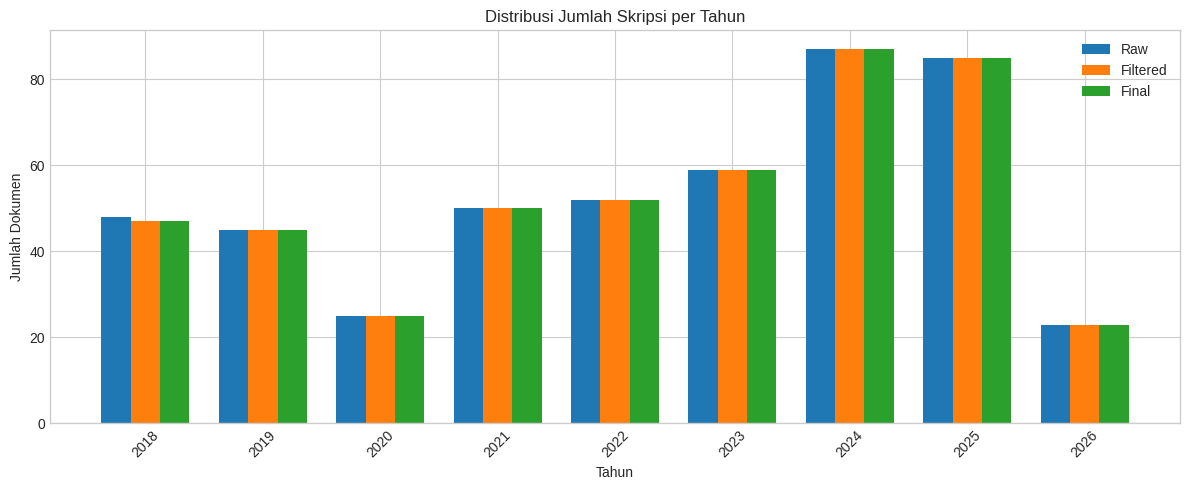

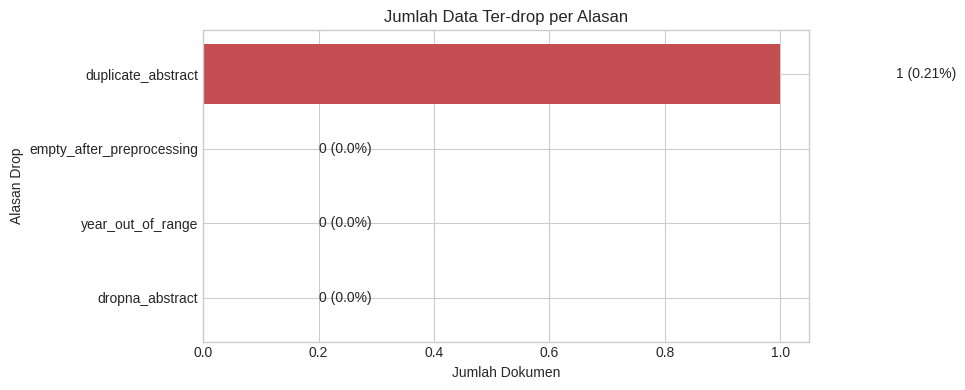

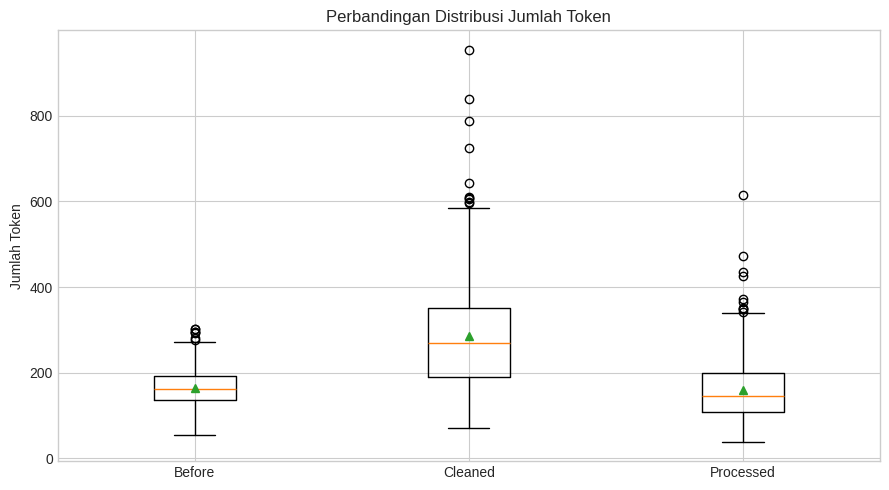

Saved plot: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_topic_models/run_20260416-132025/eda_for_report/eda_year_distribution_raw_vs_final.png
Saved plot: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_topic_models/run_20260416-132025/eda_for_report/eda_drop_reason_bar.png
Saved plot: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_topic_models/run_20260416-132025/eda_for_report/eda_token_boxplot.png


In [9]:
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except Exception:
    pass

year_plot_path = EDA_DIR / "eda_year_distribution_raw_vs_final.png"
drop_plot_path = EDA_DIR / "eda_drop_reason_bar.png"
token_plot_path = EDA_DIR / "eda_token_boxplot.png"

if not eda_year_distribution_df.empty:
    x_labels = eda_year_distribution_df["year"].astype(str).tolist()
    x_pos = np.arange(len(x_labels))
    bar_width = 0.25

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x_pos - bar_width, eda_year_distribution_df["count_raw"], width=bar_width, label="Raw")
    ax.bar(x_pos, eda_year_distribution_df["count_filtered"], width=bar_width, label="Filtered")
    ax.bar(x_pos + bar_width, eda_year_distribution_df["count_final"], width=bar_width, label="Final")

    ax.set_title("Distribusi Jumlah Skripsi per Tahun")
    ax.set_xlabel("Tahun")
    ax.set_ylabel("Jumlah Dokumen")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, rotation=45)
    ax.legend()

    fig.tight_layout()
    fig.savefig(year_plot_path, dpi=170, bbox_inches="tight")
    plt.show()
else:
    print("Year distribution kosong, plot per tahun tidak dibuat.")

if not eda_drop_reason_df.empty:
    drop_plot_df = eda_drop_reason_df.sort_values("count", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(drop_plot_df["reason"], drop_plot_df["count"], color="#C44E52")

    ax.set_title("Jumlah Data Ter-drop per Alasan")
    ax.set_xlabel("Jumlah Dokumen")
    ax.set_ylabel("Alasan Drop")

    for bar, pct in zip(bars, drop_plot_df["pct_of_raw"]):
        width = bar.get_width()
        ax.text(width + 0.2, bar.get_y() + bar.get_height() / 2, f"{int(width)} ({pct}%)", va="center")

    fig.tight_layout()
    fig.savefig(drop_plot_path, dpi=170, bbox_inches="tight")
    plt.show()
else:
    print("Drop summary kosong, plot data ter-drop tidak dibuat.")

if not before_after_df.empty:
    token_before = pd.to_numeric(before_after_df["token_before"], errors="coerce").dropna()
    token_cleaned = pd.to_numeric(before_after_df["token_cleaned"], errors="coerce").dropna()
    token_processed = pd.to_numeric(before_after_df["token_processed"], errors="coerce").dropna()

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.boxplot(
        [token_before, token_cleaned, token_processed],
        tick_labels=["Before", "Cleaned", "Processed"],
        showmeans=True,
    )
    ax.set_title("Perbandingan Distribusi Jumlah Token")
    ax.set_ylabel("Jumlah Token")

    fig.tight_layout()
    fig.savefig(token_plot_path, dpi=170, bbox_inches="tight")
    plt.show()
else:
    print("before_after_df kosong, boxplot token tidak dibuat.")

print("Saved plot:", year_plot_path)
print("Saved plot:", drop_plot_path)
print("Saved plot:", token_plot_path)

In [10]:
def _build_drop_preview(df: pd.DataFrame, reason: str, max_rows: int = 15) -> pd.DataFrame:
    if df is None or df.empty:
        return pd.DataFrame(columns=["drop_reason", "id", "title", "year", "abstract_preview"])

    candidate_cols = ["id", "title", "year", "abstract"]
    available_cols = [col for col in candidate_cols if col in df.columns]
    preview = df[available_cols].copy().head(max_rows)

    if "abstract" in preview.columns:
        preview["abstract_preview"] = (
            preview["abstract"].fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.slice(0, 220)
        )
        preview = preview.drop(columns=["abstract"])

    preview.insert(0, "drop_reason", reason)
    return preview


dropped_preview_df = pd.concat(
    [
        _build_drop_preview(dropna_df, "dropna_abstract"),
        _build_drop_preview(duplicate_df, "duplicate_abstract"),
        _build_drop_preview(year_drop_df, "year_out_of_range"),
        _build_drop_preview(empty_after_df, "empty_after_preprocessing"),
    ],
    ignore_index=True,
)

if "year" in year_drop_df.columns and not year_drop_df.empty:
    year_drop_distribution_df = (
        pd.to_numeric(year_drop_df["year"], errors="coerce")
        .dropna()
        .astype(int)
        .value_counts()
        .sort_index()
        .rename_axis("year")
        .reset_index(name="count_dropped")
    )
else:
    year_drop_distribution_df = pd.DataFrame(columns=["year", "count_dropped"])

dropped_preview_path = EDA_DIR / "eda_dropped_records_preview.csv"
year_drop_distribution_path = EDA_DIR / "eda_year_out_of_range_distribution.csv"

dropped_preview_df.to_csv(dropped_preview_path, index=False)
year_drop_distribution_df.to_csv(year_drop_distribution_path, index=False)

print("Saved:", dropped_preview_path)
print("Saved:", year_drop_distribution_path)

print("Contoh data ter-drop (maks 15 baris per alasan):")
display(dropped_preview_df.head(40))

if not year_drop_distribution_df.empty:
    print("Distribusi tahun pada data yang ter-drop karena di luar rentang:")
    display(year_drop_distribution_df)
else:
    print("Tidak ada data ter-drop karena year_out_of_range atau kolom year tidak tersedia.")

Saved: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_topic_models/run_20260416-132025/eda_for_report/eda_dropped_records_preview.csv
Saved: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_topic_models/run_20260416-132025/eda_for_report/eda_year_out_of_range_distribution.csv
Contoh data ter-drop (maks 15 baris per alasan):


,drop_reason,id,title,year,abstract_preview
0,duplicate_abstract,462,Pengembangan Sistem Informasi Reporting Nilai ...,2018,Dalam meningkatkan kualitas pendidikan yang me...


Tidak ada data ter-drop karena year_out_of_range atau kolom year tidak tersedia.


## 3) Loop Tuning BERTopic dan LDA

- BERTopic: embedding dihitung sekali di awal, lalu dipakai ulang ke semua skenario.
- LDA: loop standar per skenario.
- Kombinasi skenario adalah **fixed curated combos** (tanpa random sampling).
- Jumlah skenario final: **TUNING_COMBO_COUNT kombinasi BERTopic + TUNING_COMBO_COUNT kombinasi LDA** (default 20, opsional 24).
- DTA tidak dihitung di loop agar tuning lebih cepat; DTA dijalankan di tahap final.
- Semua hasil loop diekspor ke CSV.

In [11]:
def normalize_nr_topics(value):
    if value is None:
        return None
    text = str(value).strip().lower()
    if text in {"", "none", "null"}:
        return None
    if text == "auto":
        return "auto"
    return max(8, int(float(text)))


def apply_topic_floor_penalty(score, num_topics, min_topics=8, penalty=0.20):
    base_score = float(score or 0.0)
    if num_topics is None:
        return base_score, False
    try:
        topic_count = int(num_topics)
    except (TypeError, ValueError):
        return base_score, False

    if topic_count >= int(min_topics):
        return base_score, False

    shortfall = int(min_topics) - topic_count
    multiplier = max(0.0, 1.0 - float(penalty) * shortfall)
    return base_score * multiplier, True


def make_bertopic_params(combo):
    ngram = combo["n_gram_range"]
    if not isinstance(ngram, (list, tuple)) or len(ngram) != 2:
        raise ValueError(f"Invalid n_gram_range: {ngram}")

    return BERTopicHyperparameters(
        embedding_model=str(combo["embedding_model"]),
        min_topic_size=int(combo["min_topic_size"]),
        nr_topics=normalize_nr_topics(combo["nr_topics"]),
        top_n_words=int(combo["top_n_words"]),
        n_gram_range=[int(ngram[0]), int(ngram[1])],
        vectorizer_min_df=int(combo["vectorizer_min_df"]),
        vectorizer_max_df=float(combo["vectorizer_max_df"]),
        vectorizer_token_pattern=str(combo["vectorizer_token_pattern"]),
        vectorizer_fallback_min_df=int(combo["vectorizer_fallback_min_df"]),
        vectorizer_fallback_max_df=float(combo["vectorizer_fallback_max_df"]),
        coherence_type=str(combo["coherence_type"]),
        coherence_tokenization=str(combo["coherence_tokenization"]),
        coherence_dict_no_below=int(combo["coherence_dict_no_below"]),
        coherence_dict_no_above=float(combo["coherence_dict_no_above"]),
        reduce_outliers=bool(combo["reduce_outliers"]),
        reduce_outliers_threshold_ctfidf=float(combo["reduce_outliers_threshold_ctfidf"]),
        reduce_outliers_use_distributions=bool(combo["reduce_outliers_use_distributions"]),
        reduce_outliers_threshold_distributions=float(combo["reduce_outliers_threshold_distributions"]),
        use_mmr_representation=bool(combo["use_mmr_representation"]),
        mmr_diversity=float(combo["mmr_diversity"]),
        embedding_batch_size=int(combo["embedding_batch_size"]),
        seed=int(combo.get("seed", 42)),
        umap_params=UMAPHyperparameters(
            n_neighbors=int(combo["umap_n_neighbors"]),
            n_components=int(combo["umap_n_components"]),
            min_dist=float(combo["umap_min_dist"]),
            metric=str(combo["umap_metric"]),
            random_state=int(combo["umap_random_state"]),
        ),
        hdbscan_params=HDBSCANHyperparameters(
            min_cluster_size=int(combo["hdbscan_min_cluster_size"]),
            min_samples=None if combo["hdbscan_min_samples"] is None else int(combo["hdbscan_min_samples"]),
            metric=str(combo["hdbscan_metric"]),
            cluster_selection_method=str(combo["hdbscan_cluster_selection_method"]),
        ),
    )


def make_lda_params(combo):
    return LDAHyperparameters(
        num_topics=int(combo["num_topics"]),
        passes=int(combo["passes"]),
        iterations=int(combo["iterations"]),
        chunksize=int(combo["chunksize"]),
        random_state=int(combo["random_state"]),
        alpha=combo["alpha"],
        eta=combo["eta"],
        no_below=int(combo["no_below"]),
        no_above=float(combo["no_above"]),
    )

if "BERTOPIC_TUNING_COMBOS" not in globals() or "LDA_TUNING_COMBOS" not in globals():
    raise ValueError("Kombinasi tuning belum dibentuk. Jalankan Cell 7 terlebih dulu.")

if len(BERTOPIC_TUNING_COMBOS) != TuningConfig.TUNING_COMBO_COUNT or len(LDA_TUNING_COMBOS) != TuningConfig.TUNING_COMBO_COUNT:
    raise ValueError(f"Jumlah kombinasi harus tepat {TuningConfig.TUNING_COMBO_COUNT} untuk BERTopic dan LDA.")


bertopic_scenarios = [
    {
        "scenario_id": f"bertopic_{idx:03d}",
        "combo": combo,
        "params": make_bertopic_params(combo),
    }
    for idx, combo in enumerate(BERTOPIC_TUNING_COMBOS, start=1)
]

lda_scenarios = [
    {
        "scenario_id": f"lda_{idx:03d}",
        "combo": combo,
        "params": make_lda_params(combo),
    }
    for idx, combo in enumerate(LDA_TUNING_COMBOS, start=1)
]

scenario_df = pd.DataFrame(
    [{"model": "BERTopic", "scenario_id": s["scenario_id"], "combo": json.dumps(s["combo"], ensure_ascii=False)} for s in bertopic_scenarios]
    + [{"model": "LDA", "scenario_id": s["scenario_id"], "combo": json.dumps(s["combo"], ensure_ascii=False)} for s in lda_scenarios]
)
scenario_path = RUN_DIR / "scenario_space.csv"
scenario_df.to_csv(scenario_path, index=False)

print("SCENARIO_PLAN:", TuningConfig.SCENARIO_PLAN)
print("BERTopic selected scenarios:", len(bertopic_scenarios))
print("LDA selected scenarios:", len(lda_scenarios))
display(scenario_df.head(10))


evaluator = TopicEvaluator()

# BERTopic: compute embeddings ONCE, reuse across all scenarios.
shared_embeddings = None
if bertopic_scenarios:
    embedding_models = {s["params"].embedding_model for s in bertopic_scenarios}
    if len(embedding_models) != 1:
        raise ValueError("Untuk shared embedding, semua skenario BERTopic harus memakai embedding_model yang sama.")

    print("Computing BERTopic embeddings once...")
    embedding_trainer = BERTopicTrainer(params=bertopic_scenarios[0]["params"])
    shared_embeddings = embedding_trainer.compute_embeddings(bertopic_docs)
    np.save(RUN_DIR / "bertopic_shared_embeddings.npy", shared_embeddings)
    print("Shared embeddings shape:", shared_embeddings.shape)

bertopic_rows = []
bertopic_success_payloads = []

for idx, scenario in enumerate(bertopic_scenarios, start=1):
    print(f"[BERTopic {idx}/{len(bertopic_scenarios)}] {scenario['scenario_id']}")
    row = {
        "model": "BERTopic",
        "scenario_id": scenario["scenario_id"],
        "status": "ok",
    }

    try:
        trainer = BERTopicTrainer(params=scenario["params"])
        train_result = trainer.train(
            documents=bertopic_docs,
            embeddings=shared_embeddings,
            timestamps=timestamps if TuningConfig.RUN_DTA_IN_TUNING_LOOP else None,
            document_ids=document_ids,
        )

        metrics = evaluator.evaluate_bertopic(
            model=trainer.model,
            documents=bertopic_docs,
            topics=trainer.topics,
            vectorizer_model=trainer.vectorizer_model,
            coherence_type=trainer.params.coherence_type,
            coherence_tokenization=trainer.params.coherence_tokenization,
            coherence_dict_no_below=trainer.params.coherence_dict_no_below,
            coherence_dict_no_above=trainer.params.coherence_dict_no_above,
            top_n_words=trainer.params.top_n_words,
        )

        num_topics_value = metrics.get("num_topics", train_result.get("num_topics"))
        objective_score_raw = float(metrics.get("score_cv_td", metrics.get("score", 0.0)) or 0.0)
        
        objective_score, topic_floor_penalized = apply_topic_floor_penalty(
            objective_score_raw, num_topics_value, min_topics=TuningConfig.MIN_TARGET_TOPICS, penalty=TuningConfig.TOPIC_SHORTFALL_PENALTY
        )

        row.update({
            "objective_score": objective_score,
            "objective_score_raw": objective_score_raw,
            "topic_floor_penalized": bool(topic_floor_penalized),
            "coherence_cv": metrics.get("coherence_cv"),
            "topic_diversity": metrics.get("topic_diversity"),
            "num_topics": num_topics_value,
            "num_outliers_before_reduce": train_result.get("num_outliers_before_reduce"),
            "num_outliers_after_reduce": train_result.get("num_outliers", metrics.get("num_outliers")),
            "num_outliers": metrics.get("num_outliers", train_result.get("num_outliers")),
            "outlier_pct": metrics.get("outlier_pct"),
            "runtime_seconds": train_result.get("training_duration_seconds"),
            "params_json": json.dumps(scenario["params"].model_dump(), ensure_ascii=False),
        })

        bertopic_success_payloads.append({
            "scenario": scenario,
            "trainer": trainer,
            "train_result": train_result,
            "metrics": metrics,
            "objective_score": objective_score,
            "objective_score_raw": objective_score_raw,
        })

    except Exception as exc:
        row["status"] = "failed"
        row["error"] = str(exc)
        row["params_json"] = json.dumps(scenario["params"].model_dump(), ensure_ascii=False)

    bertopic_rows.append(row)

bertopic_results_df = pd.DataFrame(bertopic_rows)
if not bertopic_results_df.empty and "objective_score" in bertopic_results_df.columns:
    bertopic_results_df["objective_score"] = pd.to_numeric(bertopic_results_df["objective_score"], errors="coerce")
    bertopic_results_df = bertopic_results_df.sort_values("objective_score", ascending=False, na_position="last").reset_index(drop=True)

bertopic_results_path = RUN_DIR / "bertopic_loop_results.csv"
bertopic_results_df.to_csv(bertopic_results_path, index=False)

best_bertopic_payload = None
if bertopic_success_payloads:
    best_bertopic_payload = max(bertopic_success_payloads, key=lambda x: float(x.get("objective_score", 0.0) or 0.0))


lda_rows = []
lda_success_payloads = []

for idx, scenario in enumerate(lda_scenarios, start=1):
    print(f"[LDA {idx}/{len(lda_scenarios)}] {scenario['scenario_id']}")
    row = {
        "model": "LDA",
        "scenario_id": scenario["scenario_id"],
        "status": "ok",
    }

    try:
        trainer = LDATrainer(params=scenario["params"])
        train_result = trainer.train(
            documents=lda_docs,
            timestamps=timestamps if TuningConfig.RUN_TEMPORAL_DIST_IN_LDA_LOOP else None,
        )

        metrics = evaluator.evaluate_lda(
            model=trainer.model,
            tokenized_docs=trainer.tokenized_docs,
            dictionary=trainer.dictionary,
        )

        num_topics_value = metrics.get("num_topics", train_result.get("num_topics"))
        objective_score_raw = float(metrics.get("score", 0.0) or 0.0)
        
        objective_score, topic_floor_penalized = apply_topic_floor_penalty(
            objective_score_raw, num_topics_value, min_topics=TuningConfig.MIN_TARGET_TOPICS, penalty=TuningConfig.TOPIC_SHORTFALL_PENALTY
        )

        row.update({
            "objective_score": objective_score,
            "objective_score_raw": objective_score_raw,
            "topic_floor_penalized": bool(topic_floor_penalized),
            "coherence_cv": metrics.get("coherence_cv"),
            "topic_diversity": metrics.get("topic_diversity"),
            "num_topics": num_topics_value,
            "runtime_seconds": train_result.get("training_duration_seconds"),
            "params_json": json.dumps(scenario["params"].model_dump(), ensure_ascii=False),
        })

        lda_success_payloads.append({
            "scenario": scenario,
            "trainer": trainer,
            "train_result": train_result,
            "metrics": metrics,
            "objective_score": objective_score,
            "objective_score_raw": objective_score_raw,
        })

    except Exception as exc:
        row["status"] = "failed"
        row["error"] = str(exc)
        row["params_json"] = json.dumps(scenario["params"].model_dump(), ensure_ascii=False)

    lda_rows.append(row)

lda_results_df = pd.DataFrame(lda_rows)
if not lda_results_df.empty and "objective_score" in lda_results_df.columns:
    lda_results_df["objective_score"] = pd.to_numeric(lda_results_df["objective_score"], errors="coerce")
    lda_results_df = lda_results_df.sort_values("objective_score", ascending=False, na_position="last").reset_index(drop=True)

lda_results_path = RUN_DIR / "lda_loop_results.csv"
lda_results_df.to_csv(lda_results_path, index=False)

best_lda_payload = None
if lda_success_payloads:
    best_lda_payload = max(lda_success_payloads, key=lambda x: float(x.get("objective_score", 0.0) or 0.0))

comparison_rows = []
if not bertopic_results_df.empty:
    ok_b = bertopic_results_df[bertopic_results_df["status"] == "ok"].copy()
    for _, r in ok_b.iterrows():
        comparison_rows.append({
            "model": "BERTopic",
            "scenario_id": r.get("scenario_id"),
            "objective_score": r.get("objective_score"),
            "coherence_cv": r.get("coherence_cv"),
            "topic_diversity": r.get("topic_diversity"),
            "runtime_seconds": r.get("runtime_seconds"),
            "num_topics": r.get("num_topics"),
        })

if not lda_results_df.empty:
    ok_l = lda_results_df[lda_results_df["status"] == "ok"].copy()
    for _, r in ok_l.iterrows():
        comparison_rows.append({
            "model": "LDA",
            "scenario_id": r.get("scenario_id"),
            "objective_score": r.get("objective_score"),
            "coherence_cv": r.get("coherence_cv"),
            "topic_diversity": r.get("topic_diversity"),
            "runtime_seconds": r.get("runtime_seconds"),
            "num_topics": r.get("num_topics"),
        })

leaderboard_df = pd.DataFrame(comparison_rows)


def _minmax(series):
    values = pd.to_numeric(series, errors="coerce")
    cmin = values.min()
    cmax = values.max()
    if pd.isna(cmin) or pd.isna(cmax) or cmin == cmax:
        return pd.Series(0.5, index=values.index, dtype=float)
    return (values - cmin) / (cmax - cmin)


if not leaderboard_df.empty:
    leaderboard_df["objective_norm"] = _minmax(leaderboard_df["objective_score"])
    leaderboard_df["coherence_norm"] = _minmax(leaderboard_df["coherence_cv"])
    leaderboard_df["diversity_norm"] = _minmax(leaderboard_df["topic_diversity"])
    leaderboard_df["runtime_norm"] = 1 - _minmax(leaderboard_df["runtime_seconds"])

    leaderboard_df["composite_score"] = (
        0.45 * leaderboard_df["objective_norm"]
        + 0.30 * leaderboard_df["coherence_norm"]
        + 0.20 * leaderboard_df["diversity_norm"]
        + 0.05 * leaderboard_df["runtime_norm"]
    )

    leaderboard_df = leaderboard_df.sort_values(
        ["composite_score", "objective_score", "coherence_cv"],
        ascending=[False, False, False],
        na_position="last",
    ).reset_index(drop=True)
    leaderboard_df["rank"] = np.arange(1, len(leaderboard_df) + 1)

comparison_path = RUN_DIR / "model_comparison_leaderboard.csv"
leaderboard_df.to_csv(comparison_path, index=False)

print("BERTopic loop rows:", len(bertopic_results_df))
print("LDA loop rows:", len(lda_results_df))
if not bertopic_results_df.empty and "topic_floor_penalized" in bertopic_results_df.columns:
    print("BERTopic penalized (< MIN_TARGET_TOPICS):", int(bertopic_results_df["topic_floor_penalized"].fillna(False).sum()))
if not lda_results_df.empty and "topic_floor_penalized" in lda_results_df.columns:
    print("LDA penalized (< MIN_TARGET_TOPICS):", int(lda_results_df["topic_floor_penalized"].fillna(False).sum()))
display(leaderboard_df.head(10))

SCENARIO_PLAN: fixed_24_curated_combos
BERTopic selected scenarios: 24
LDA selected scenarios: 24


,model,scenario_id,combo
0,BERTopic,bertopic_001,"{""embedding_model"": ""denaya/indoSBERT-large"", ..."
1,BERTopic,bertopic_002,"{""embedding_model"": ""denaya/indoSBERT-large"", ..."
2,BERTopic,bertopic_003,"{""embedding_model"": ""denaya/indoSBERT-large"", ..."
3,BERTopic,bertopic_004,"{""embedding_model"": ""denaya/indoSBERT-large"", ..."
4,BERTopic,bertopic_005,"{""embedding_model"": ""denaya/indoSBERT-large"", ..."
5,BERTopic,bertopic_006,"{""embedding_model"": ""denaya/indoSBERT-large"", ..."
6,BERTopic,bertopic_007,"{""embedding_model"": ""denaya/indoSBERT-large"", ..."
7,BERTopic,bertopic_008,"{""embedding_model"": ""denaya/indoSBERT-large"", ..."
8,BERTopic,bertopic_009,"{""embedding_model"": ""denaya/indoSBERT-large"", ..."
9,BERTopic,bertopic_010,"{""embedding_model"": ""denaya/indoSBERT-large"", ..."


2026-04-16 13:25:14.805 | INFO     | app.ml.bertopic_trainer:compute_embeddings:335 - Computing sentence embeddings for 473 documents using denaya/indoSBERT-large...
2026-04-16 13:25:14.806 | INFO     | app.ml.bertopic_trainer:_build_embedding_model:175 - Loading sentence encoder: denaya/indoSBERT-large (IndoBERT-large + Siamese Network, output: 256-dim)


Computing BERTopic embeddings once...


Batches: 100%|██████████| 30/30 [08:09<00:00, 16.31s/it]
2026-04-16 13:33:32.833 | INFO     | app.ml.bertopic_trainer:compute_embeddings:368 - Embeddings shape: (473, 256) (dim=256)
2026-04-16 13:33:32.850 | INFO     | app.ml.bertopic_trainer:train:390 - Starting BERTopic training on 473 documents
2026-04-16 13:33:32.856 | INFO     | app.ml.bertopic_trainer:train:391 - Embedding model: denaya/indoSBERT-large (256-dim)


...

2026-04-16 14:14:02.511 | INFO     | app.ml.lda_trainer:train:139 - LDA training complete in 6.86s
2026-04-16 14:14:02.513 | INFO     | app.ml.evaluator:compute_coherence_gensim:44 - Computing c_v coherence for LDA...
2026-04-16 14:14:03.645 | INFO     | app.ml.evaluator:compute_coherence_gensim:54 - LDA Coherence (c_v): 0.3588
2026-04-16 14:14:03.647 | INFO     | app.ml.evaluator:compute_topic_diversity:131 - Topic Diversity: 0.4938 (79 unique / 160 total words)
2026-04-16 14:14:03.648 | INFO     | app.ml.lda_trainer:train:108 - Starting LDA training on 473 documents
2026-04-16 14:14:03.709 | INFO     | app.ml.lda_trainer:_build_dictionary:67 - Dictionary built: 1435 unique tokens (after filtering: no_below=4, no_above=0.95)
2026-04-16 14:14:03.739 | INFO     | app.ml.lda_trainer:_build_corpus:77 - Corpus built: 473 documents
2026-04-16 14:14:03.739 | INFO     | app.ml.lda_trainer:train:120 - Training LDA with 10 topics, 10 passes (model: LdaModel deterministic, alpha=0.1, eta=0.1)...

[LDA 24/24] lda_024


2026-04-16 14:14:10.397 | INFO     | app.ml.lda_trainer:train:139 - LDA training complete in 6.75s
2026-04-16 14:14:10.399 | INFO     | app.ml.evaluator:compute_coherence_gensim:44 - Computing c_v coherence for LDA...
2026-04-16 14:14:11.362 | INFO     | app.ml.evaluator:compute_coherence_gensim:54 - LDA Coherence (c_v): 0.3848
2026-04-16 14:14:11.365 | INFO     | app.ml.evaluator:compute_topic_diversity:131 - Topic Diversity: 0.5200 (52 unique / 100 total words)


BERTopic loop rows: 24
LDA loop rows: 24
BERTopic penalized (< MIN_TARGET_TOPICS): 9
LDA penalized (< MIN_TARGET_TOPICS): 0


,model,scenario_id,objective_score,coherence_cv,topic_diversity,runtime_seconds,num_topics,objective_norm,coherence_norm,diversity_norm,runtime_norm,composite_score,rank
0,BERTopic,bertopic_017,0.632755,0.5182,0.8455,111.59,11,1.000000,0.686441,0.785219,0.442873,0.835120,1
1,BERTopic,bertopic_006,0.623025,0.4685,0.9100,68.10,10,0.984623,0.517966,0.909353,0.672384,0.813960,2
2,BERTopic,bertopic_021,0.608705,0.4399,0.9222,101.98,9,0.961992,0.421017,0.932833,0.493588,0.770447,3
3,BERTopic,bertopic_019,0.603665,0.4441,0.9000,100.68,11,0.954026,0.435254,0.890108,0.500449,0.762932,4
4,BERTopic,bertopic_004,0.593100,0.4398,0.8778,115.98,9,0.937330,0.420678,0.847383,0.419706,0.738464,5
5,BERTopic,bertopic_007,0.591380,0.4301,0.8909,97.37,11,0.934611,0.387797,0.872594,0.517917,0.737329,6
6,BERTopic,bertopic_013,0.589105,0.4364,0.8727,96.52,11,0.931016,0.409153,0.837567,0.522402,0.735337,7
7,BERTopic,bertopic_014,0.587805,0.4197,0.9000,73.21,12,0.928961,0.352542,0.890108,0.645417,0.734088,8
8,BERTopic,bertopic_016,0.587820,0.4341,0.8733,125.46,15,0.928985,0.401356,0.838722,0.369677,0.724678,9
9,BERTopic,bertopic_010,0.499624,0.4608,0.9286,79.55,7,0.789601,0.491864,0.945150,0.611958,0.722508,10


## 4) Retrain Best Model + Simpan Artefak

Notebook ini retrain best BERTopic dan best LDA dari hasil loop, lalu menyimpan model + best config + keyword topic ke CSV/JSON.

In [12]:
def to_serializable(obj):
    if isinstance(obj, dict):
        return {k: to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_serializable(v) for v in obj]
    if isinstance(obj, tuple):
        return [to_serializable(v) for v in obj]
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


def write_json(path, payload):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(to_serializable(payload), f, ensure_ascii=False, indent=2)


def save_bertopic_with_fallback(trainer, job_id):
    try:
        return trainer.save_model(job_id)
    except PermissionError as exc:
        fallback_dir = RUN_DIR / "saved_models" / f"bertopic_{job_id}"
        fallback_dir.mkdir(parents=True, exist_ok=True)
        trainer.model.save(str(fallback_dir / "model"), serialization="safetensors", save_ctfidf=True)
        if getattr(trainer, "embeddings", None) is not None:
            np.save(str(fallback_dir / "embeddings.npy"), trainer.embeddings)
        write_json(
            fallback_dir / "metadata.json",
            {
                "job_id": job_id,
                "model_type": "bertopic",
                "save_mode": "fallback_notebook",
                "reason": str(exc),
                "saved_at": datetime.now().isoformat(),
            },
        )
        return str(fallback_dir)


def save_lda_with_fallback(trainer, job_id):
    try:
        return trainer.save_model(job_id)
    except PermissionError as exc:
        fallback_dir = RUN_DIR / "saved_models" / f"lda_{job_id}"
        fallback_dir.mkdir(parents=True, exist_ok=True)
        trainer.model.save(str(fallback_dir / "lda_model"))
        trainer.dictionary.save(str(fallback_dir / "dictionary.dict"))
        write_json(
            fallback_dir / "metadata.json",
            {
                "job_id": job_id,
                "model_type": "lda",
                "save_mode": "fallback_notebook",
                "reason": str(exc),
                "saved_at": datetime.now().isoformat(),
            },
        )
        return str(fallback_dir)


final_bertopic = None
final_lda = None

if best_bertopic_payload is not None:
    params = best_bertopic_payload["scenario"]["params"]
    trainer = BERTopicTrainer(params=params)
    train_result = trainer.train(
        documents=bertopic_docs,
        embeddings=shared_embeddings,
        timestamps=None,
        document_ids=document_ids,
    )
    metrics = evaluator.evaluate_bertopic(
        model=trainer.model,
        documents=bertopic_docs,
        topics=trainer.topics,
        vectorizer_model=trainer.vectorizer_model,
        coherence_type=trainer.params.coherence_type,
        coherence_tokenization=trainer.params.coherence_tokenization,
        coherence_dict_no_below=trainer.params.coherence_dict_no_below,
        coherence_dict_no_above=trainer.params.coherence_dict_no_above,
        top_n_words=trainer.params.top_n_words,
    )
    model_path = save_bertopic_with_fallback(trainer, f"nb_best_bertopic_{RUN_TS}")
    final_bertopic = {
        "trainer": trainer,
        "params": params,
        "train_result": train_result,
        "metrics": metrics,
        "model_path": model_path,
        "scenario_id": best_bertopic_payload["scenario"]["scenario_id"],
    }

if best_lda_payload is not None:
    params = best_lda_payload["scenario"]["params"]
    trainer = LDATrainer(params=params)
    train_result = trainer.train(documents=lda_docs)
    metrics = evaluator.evaluate_lda(
        model=trainer.model,
        tokenized_docs=trainer.tokenized_docs,
        dictionary=trainer.dictionary,
    )
    model_path = save_lda_with_fallback(trainer, f"nb_best_lda_{RUN_TS}")
    final_lda = {
        "trainer": trainer,
        "params": params,
        "train_result": train_result,
        "metrics": metrics,
        "model_path": model_path,
        "scenario_id": best_lda_payload["scenario"]["scenario_id"],
    }

keyword_frames = []
if final_bertopic is not None:
    b_rows = []
    b_info = final_bertopic["trainer"].model.get_topic_info().copy()
    b_count_map = {}
    if "Topic" in b_info.columns and "Count" in b_info.columns:
        for _, rr in b_info.iterrows():
            topic_id = int(rr.get("Topic", -1))
            if topic_id != -1:
                b_count_map[topic_id] = int(rr.get("Count", 0))

    for topic_id, words_scores in (final_bertopic["trainer"].model.get_topics() or {}).items():
        topic_id = int(topic_id)
        if topic_id == -1:
            continue
        for rank, (word, score) in enumerate((words_scores or [])[:15], start=1):
            b_rows.append({
                "model": "BERTopic",
                "topic_id": topic_id,
                "topic_doc_count": b_count_map.get(topic_id, np.nan),
                "keyword_rank": rank,
                "keyword": str(word),
                "keyword_score": float(score or 0.0),
            })

    bertopic_keywords_df = pd.DataFrame(b_rows)
    if not bertopic_keywords_df.empty:
        bertopic_keywords_df.to_csv(RUN_DIR / "bertopic_topic_keywords_long.csv", index=False)
        keyword_frames.append(bertopic_keywords_df)

if final_lda is not None:
    l_rows = []
    dominant_topic_ids = []
    lda_corpus_for_count = [final_lda["trainer"].dictionary.doc2bow(str(doc).split()) for doc in lda_docs]
    for bow in lda_corpus_for_count:
        if not bow:
            continue
        dist = final_lda["trainer"].model.get_document_topics(bow, minimum_probability=0.0)
        if dist:
            dominant_topic_ids.append(int(max(dist, key=lambda x: x[1])[0]))
    l_count_map = dict(Counter(dominant_topic_ids))

    for topic_id in range(final_lda["trainer"].model.num_topics):
        for rank, (word, score) in enumerate(final_lda["trainer"].model.show_topic(topic_id, topn=15), start=1):
            l_rows.append({
                "model": "LDA",
                "topic_id": int(topic_id),
                "topic_doc_count": int(l_count_map.get(int(topic_id), 0)),
                "keyword_rank": rank,
                "keyword": str(word),
                "keyword_score": float(score or 0.0),
            })

    lda_keywords_df = pd.DataFrame(l_rows)
    if not lda_keywords_df.empty:
        lda_keywords_df.to_csv(RUN_DIR / "lda_topic_keywords_long.csv", index=False)
        keyword_frames.append(lda_keywords_df)

if keyword_frames:
    combined_keywords_df = pd.concat(keyword_frames, ignore_index=True)
    combined_keywords_df.to_csv(RUN_DIR / "topic_keywords_combined_long.csv", index=False)

metrics_rows = []
if final_bertopic is not None:
    metrics_rows.append({
        "model": "BERTopic",
        "scenario_id": final_bertopic["scenario_id"],
        "coherence_cv": final_bertopic["metrics"].get("coherence_cv"),
        "topic_diversity": final_bertopic["metrics"].get("topic_diversity"),
        "num_topics": final_bertopic["metrics"].get("num_topics"),
        "model_path": final_bertopic["model_path"],
    })
if final_lda is not None:
    metrics_rows.append({
        "model": "LDA",
        "scenario_id": final_lda["scenario_id"],
        "coherence_cv": final_lda["metrics"].get("coherence_cv"),
        "topic_diversity": final_lda["metrics"].get("topic_diversity"),
        "num_topics": final_lda["metrics"].get("num_topics"),
        "model_path": final_lda["model_path"],
    })

final_metrics_df = pd.DataFrame(metrics_rows)
final_metrics_path = RUN_DIR / "best_retrain_metrics.csv"
final_metrics_df.to_csv(final_metrics_path, index=False)

best_config_payload = {
    "timestamp": RUN_TS,
    "best_bertopic": None,
    "best_lda": None,
    "comparison_top10": leaderboard_df.head(10).to_dict(orient="records") if not leaderboard_df.empty else [],
    "artifact_dir": str(RUN_DIR),
}

if final_bertopic is not None:
    best_config_payload["best_bertopic"] = {
        "scenario_id": final_bertopic["scenario_id"],
        "params": final_bertopic["params"].model_dump(),
        "metrics": final_bertopic["metrics"],
        "model_path": final_bertopic["model_path"],
    }

if final_lda is not None:
    best_config_payload["best_lda"] = {
        "scenario_id": final_lda["scenario_id"],
        "params": final_lda["params"].model_dump(),
        "metrics": final_lda["metrics"],
        "model_path": final_lda["model_path"],
    }

best_config_path = RUN_DIR / "best_config.json"
write_json(best_config_path, best_config_payload)

display(final_metrics_df)
print("Best config saved to:", best_config_path)

2026-04-16 14:14:11.567 | INFO     | app.ml.bertopic_trainer:train:390 - Starting BERTopic training on 473 documents
2026-04-16 14:14:11.570 | INFO     | app.ml.bertopic_trainer:train:391 - Embedding model: denaya/indoSBERT-large (256-dim)
2026-04-16 14:14:11.574 | INFO     | app.ml.bertopic_trainer:train:394 - Reproducibility settings applied with seed=42
2026-04-16 14:14:11.575 | INFO     | app.ml.bertopic_trainer:_build_embedding_model:175 - Loading sentence encoder: denaya/indoSBERT-large (IndoBERT-large + Siamese Network, output: 256-dim)
2026-04-16 14:14:22.156 | INFO     | app.ml.bertopic_trainer:_build_model:324 - BERTopic model pipeline built successfully
2026-04-16 14:14:22.158 | INFO     | app.ml.bertopic_trainer:train:404 - Fitting BERTopic model (UMAP → HDBSCAN → c-TF-IDF + MMR)...
2026-04-16 14:14:22,160 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-16 14:14:24,262 - BERTopic - Dimensionality - Completed ✓
2026-04-16 14:14:24,263 - B

,model,scenario_id,coherence_cv,topic_diversity,num_topics,model_path
0,BERTopic,bertopic_017,0.5182,0.8455,11,/home/galih/MySkripsi/- Aplikasi/my-skripsi/fa...
1,LDA,lda_004,0.3583,0.6500,8,/home/galih/MySkripsi/- Aplikasi/my-skripsi/fa...


Best config saved to: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_topic_models/run_20260416-132025/best_config.json


## 5) Visualisasi + DTA (Emerging/Stable/Declining)

=== Visualisasi BERTopic ===


,Topic,Count,Name
0,0,84,0_desa_berbasis web_umkm_rancang bangun
1,1,90,1_unsoed_perancangan_audit_laporan
2,2,64,2_penjualan_transaksi_sampah_waterfall
3,3,29,3_performa_laravel_server_beban
4,4,55,4_deteksi_cnn_performa_precision
5,5,34,5_pendukung keputusan_penilaian_kriteria_simpl...
6,6,24,6_edukasi_siswa_pembelajaran_permainan
7,7,30,7_klasterisasi_klasifikasi_umkm_hama
8,8,25,8_produk_clustering_penjualan_rekomendasi
9,9,18,9_pmks_berbasis web_banjarnegara_rancang bangun



=== Visualisasi LDA ===


,topic_id,top_words
0,0,"barang, sakit, pakar, produk, website, bas, la..."
1,1,"informasi, nilai, desa, dasar, kelola, bangun,..."
2,2,"aplikasi, kembang, uji, proses, informasi, lar..."
3,3,"halaman, dasar, seleksi, nilai, uji, klaster, ..."
4,4,"game, guna, uji, kembang, user, ajar, edukasi,..."
5,5,"aplikasi, guna, ajar, bas, rekomendasi, dasar,..."
6,6,"model, nilai, prediksi, hasil, klasifikasi, ak..."
7,7,"informasi, bas, bangun, kelola, kembang, mudah..."



=== Distribusi Dokumen per Topik (Side-by-Side) ===


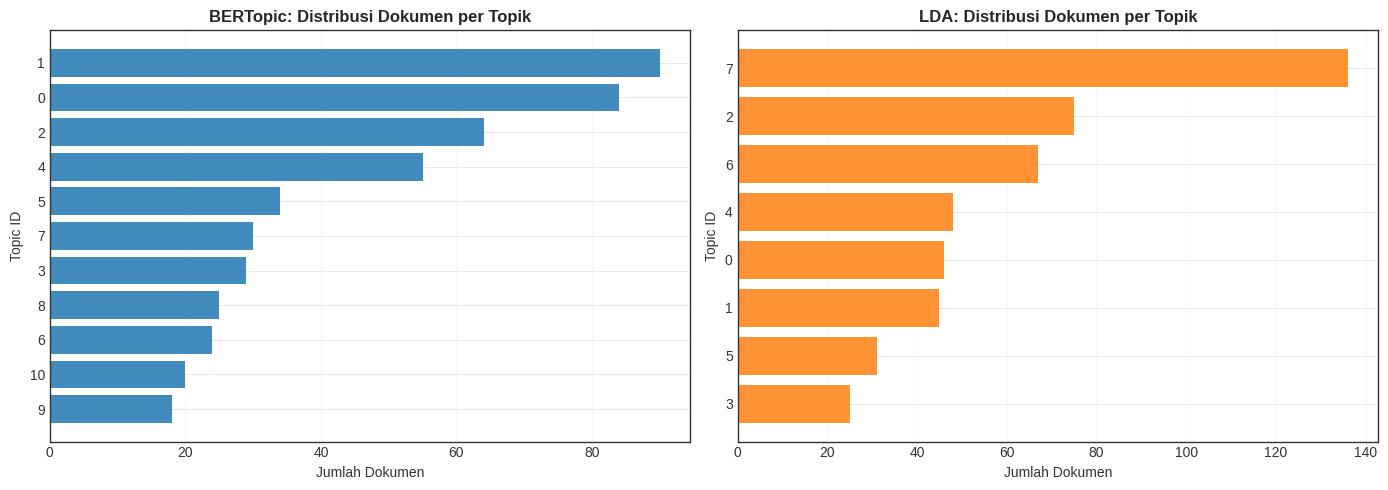


=== WordCloud per Topik (BERTopic) ===


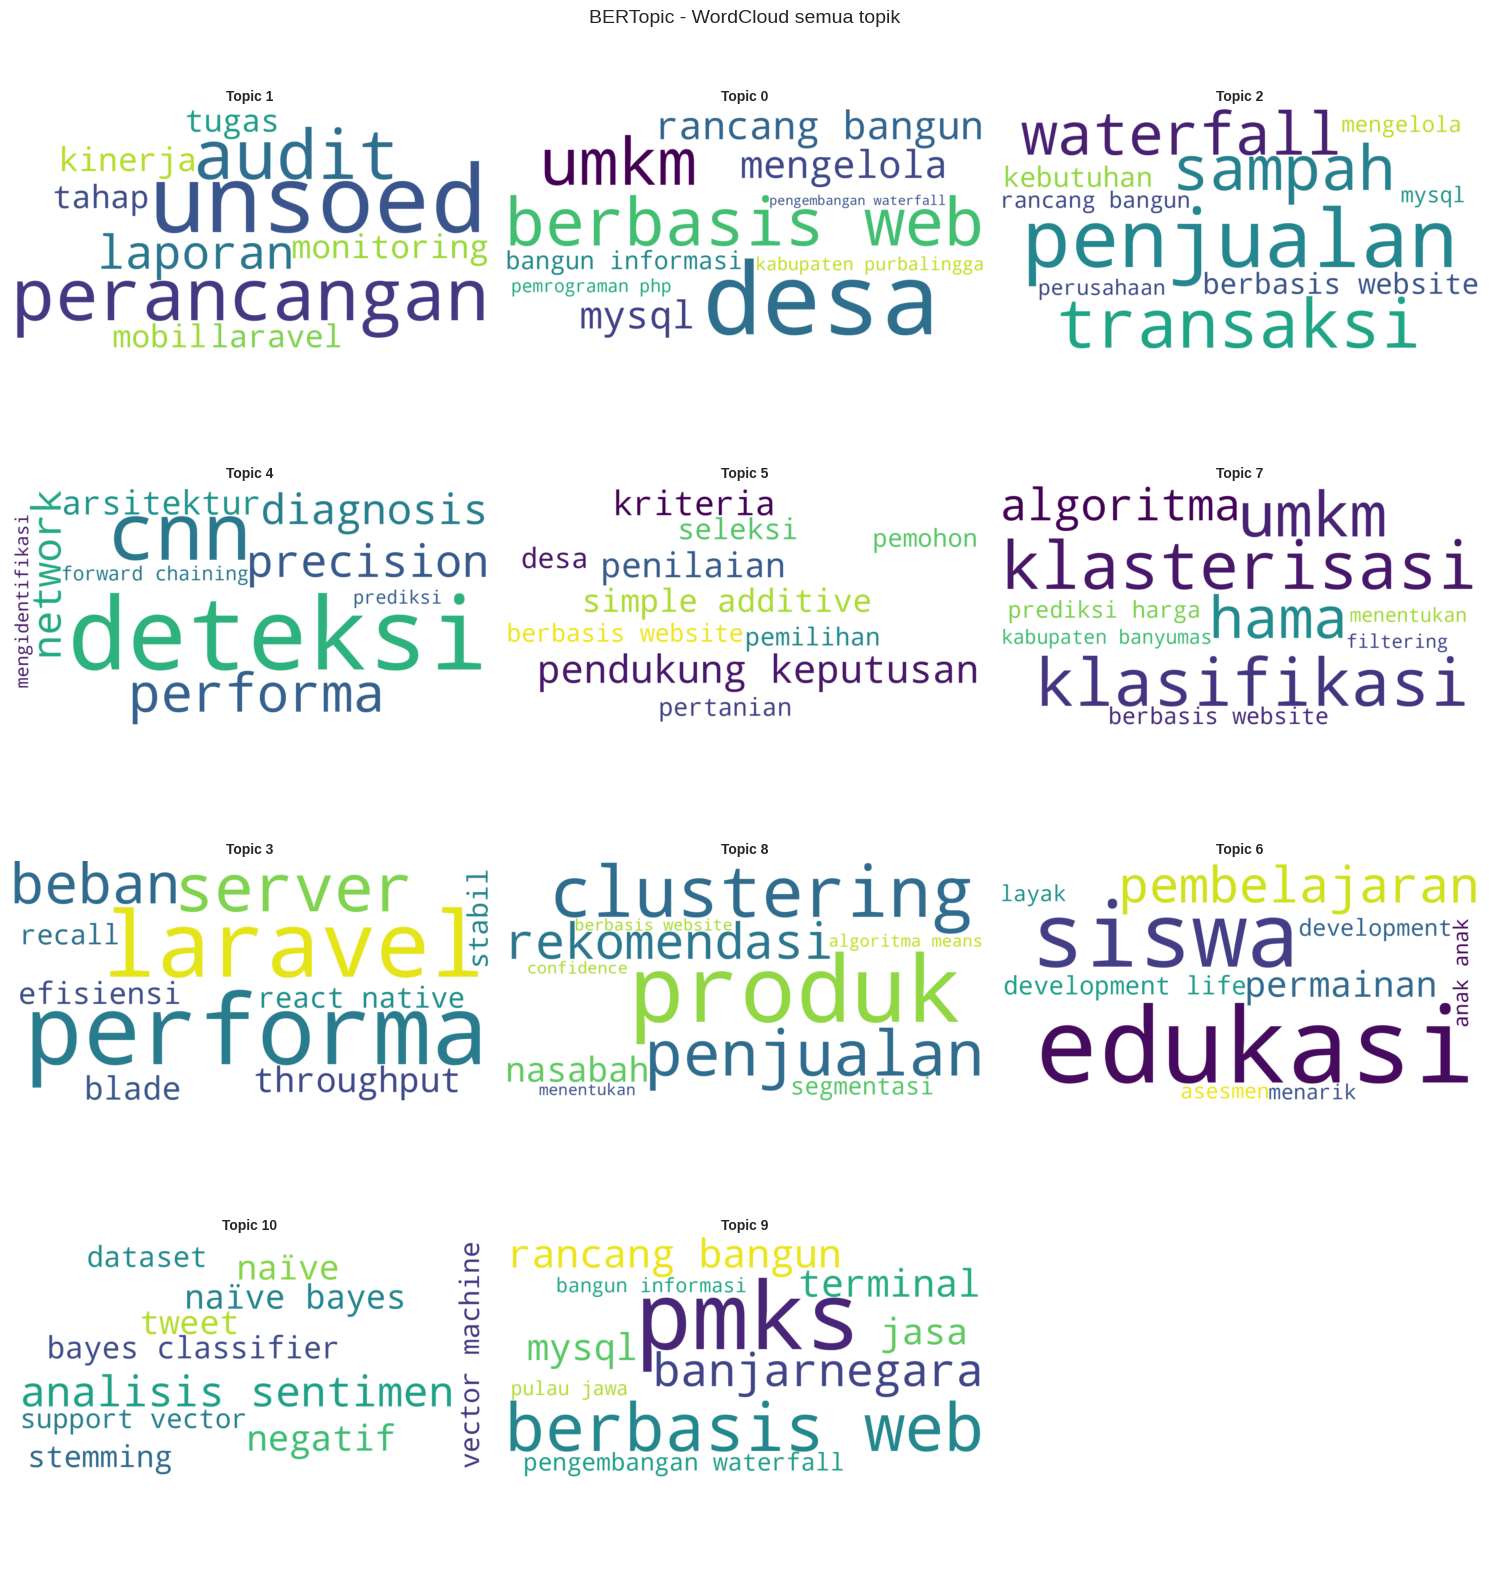


=== WordCloud per Topik (LDA) ===


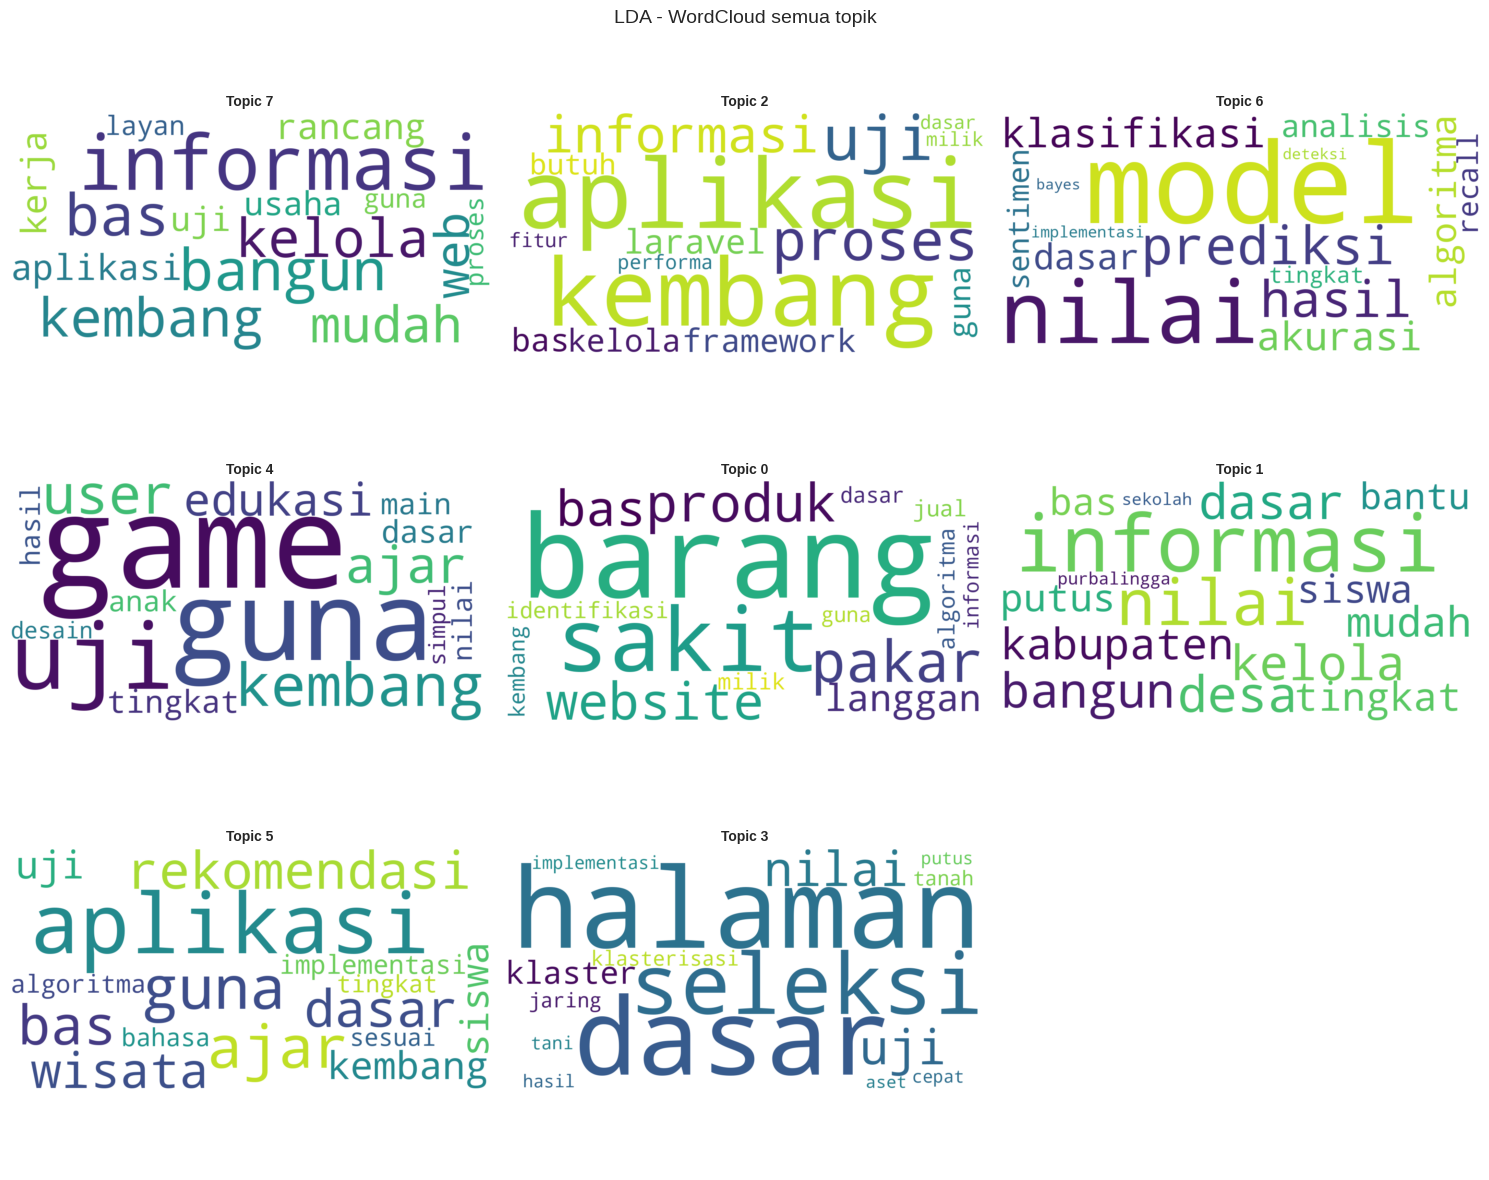


=== Perbandingan Metrics Best Model ===


,model,scenario_id,coherence_cv,topic_diversity,num_topics,model_path
0,BERTopic,bertopic_017,0.5182,0.8455,11,/home/galih/MySkripsi/- Aplikasi/my-skripsi/fa...
1,LDA,lda_004,0.3583,0.6500,8,/home/galih/MySkripsi/- Aplikasi/my-skripsi/fa...


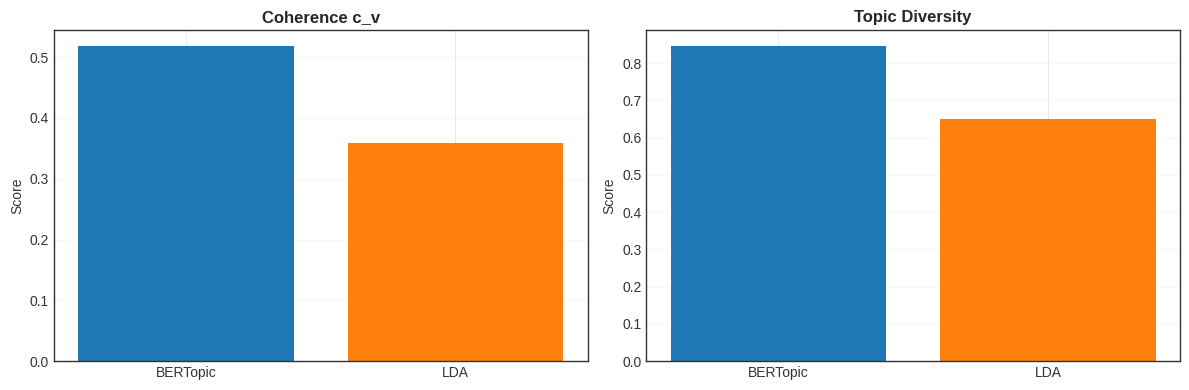


=== DTA BERTopic: Emerging / Stable / Declining ===


9it [03:35, 23.93s/it]

Ringkasan trend:


,trend_label,n_topics
0,declining,3
1,emerging,5
2,stable,3


,topic_id,trend_label,n_periods,start_frequency,end_frequency,slope,relative_slope,keywords_top10
0,2,declining,9,12.0,1.0,-1.133333e+00,-1.593750e-01,"penjualan, transaksi, sampah, waterfall, berba..."
1,0,declining,9,14.0,1.0,-1.866667e+00,-2.000000e-01,"desa, berbasis web, umkm, rancang bangun, meng..."
2,9,declining,6,3.0,1.0,-6.285714e-01,-2.095238e-01,"pmks, berbasis web, banjarnegara, rancang bang..."
3,8,emerging,6,2.0,9.0,1.628571e+00,3.908571e-01,"produk, clustering, penjualan, rekomendasi, na..."
4,6,emerging,5,1.0,7.0,1.600000e+00,3.333333e-01,"edukasi, siswa, pembelajaran, permainan, devel..."
5,3,emerging,5,3.0,3.0,1.700000e+00,2.931034e-01,"performa, laravel, server, beban, throughput, ..."
6,7,emerging,8,1.0,4.0,9.285714e-01,2.476190e-01,"klasterisasi, klasifikasi, umkm, hama, algorit..."
7,4,emerging,9,1.0,3.0,1.400000e+00,2.290909e-01,"deteksi, cnn, performa, precision, diagnosis, ..."
8,1,stable,9,7.0,6.0,7.333333e-01,7.333333e-02,"unsoed, perancangan, audit, laporan, monitorin..."
9,5,stable,8,7.0,2.0,1.428571e-01,3.361345e-02,"pendukung keputusan, penilaian, kriteria, simp..."


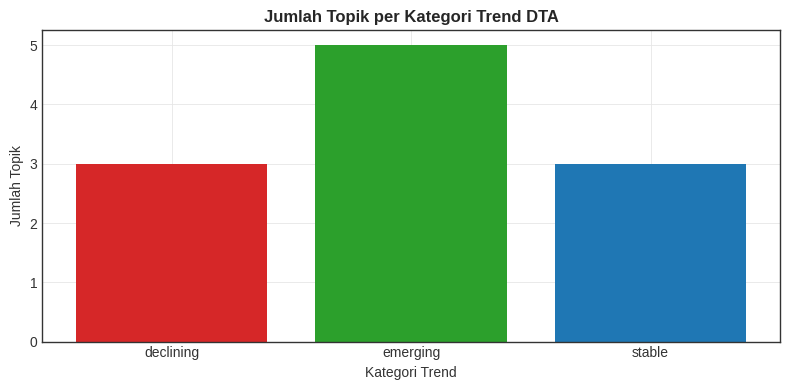

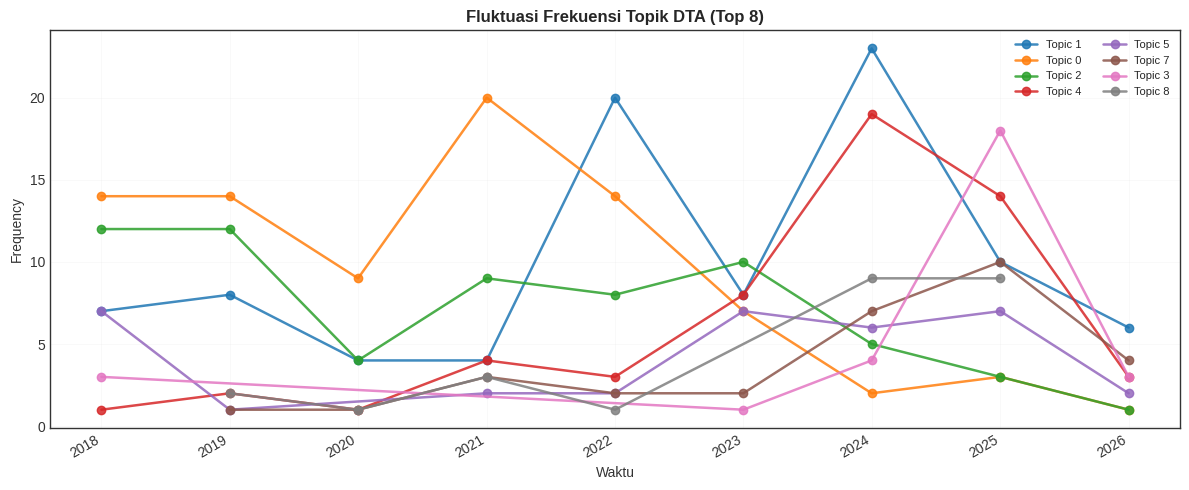

DTA artifacts:
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_topic_models/run_20260416-132025/dta_topics_over_time.csv
- /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_topic_models/run_20260416-132025/dta_topic_trend_classification.csv


In [13]:
def set_plot_style():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#333333",
        "axes.labelcolor": "#333333",
        "axes.titleweight": "bold",
        "xtick.color": "#333333",
        "ytick.color": "#333333",
        "grid.color": "#e6e6e6",
        "grid.linestyle": "-",
        "grid.linewidth": 0.6,
    })


MODEL_COLORS = {"bertopic": "#1f77b4", "lda": "#ff7f0e"}
set_plot_style()


def plot_wordcloud_grid(topic_payloads, title_text, max_topics=None, cols=3, colormap="viridis"):
    if WordCloud is None:
        print(f"{title_text} dilewati: package wordcloud belum tersedia.")
        return
    if max_topics is None:
        max_topics = len(topic_payloads)

    payloads = [p for p in topic_payloads[:max_topics] if p.get("freq")]
    if not payloads:
        print(f"{title_text} dilewati: tidak ada topik valid.")
        return

    n = len(payloads)
    cols = max(1, min(cols, n))
    rows = int(math.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, payload in zip(axes, payloads):
        wc = WordCloud(
            width=1400,
            height=700,
            background_color="white",
            colormap=colormap,
            max_words=200,
        ).generate_from_frequencies(payload["freq"])
        ax.imshow(wc, interpolation="bilinear")
        ax.set_title(payload.get("title", ""), fontsize=10)
        ax.axis("off")

    for ax in axes[n:]:
        ax.axis("off")

    fig.suptitle(title_text, fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_topic_distribution(ax, topic_df, title, color):
    if topic_df is None or topic_df.empty:
        ax.axis("off")
        ax.set_title(f"{title}: tidak ada data")
        return

    plot_df = (
        topic_df.sort_values("count", ascending=False)
        .head(min(12, len(topic_df)))
        .sort_values("count")
    )
    ax.barh(plot_df["topic_id"].astype(str), plot_df["count"], color=color, alpha=0.85)
    ax.set_title(f"{title}: Distribusi Dokumen per Topik")
    ax.set_xlabel("Jumlah Dokumen")
    ax.set_ylabel("Topic ID")
    ax.grid(axis="x", alpha=0.3)


print("=== Visualisasi BERTopic ===")
bertopic_wc_payloads = []
bertopic_dist_df = None
if final_bertopic is not None:
    b_model = final_bertopic["trainer"].model
    b_info = b_model.get_topic_info().copy()
    if "Topic" in b_info.columns:
        b_info = b_info[b_info["Topic"] != -1].copy()

    if not b_info.empty:
        cols_show = [c for c in ["Topic", "Count", "Name"] if c in b_info.columns]
        display(b_info[cols_show].head(15))

        if "Count" in b_info.columns:
            bertopic_dist_df = (
                b_info[["Topic", "Count"]]
                .rename(columns={"Topic": "topic_id", "Count": "count"})
                .sort_values("count", ascending=False)
            )
            topic_ids = b_info.sort_values("Count", ascending=False)["Topic"].astype(int).tolist()
        else:
            topic_ids = b_info["Topic"].astype(int).tolist()

        for tid in topic_ids:
            words_scores = b_model.get_topic(int(tid)) or []
            freq = {w: float(s or 0.0) for w, s in words_scores[:15] if float(s or 0.0) > 0}
            bertopic_wc_payloads.append({"title": f"Topic {int(tid)}", "freq": freq})
    else:
        print("Topic info BERTopic kosong setelah filter outlier.")
else:
    print("Best BERTopic tidak tersedia.")

print("\n=== Visualisasi LDA ===")
lda_wc_payloads = []
lda_dist_df = None
if final_lda is not None:
    l_trainer = final_lda["trainer"]
    l_model = l_trainer.model

    lda_topic_rows = []
    for topic_id in range(l_model.num_topics):
        topic_words = l_model.show_topic(topic_id, topn=15)
        lda_topic_rows.append({
            "topic_id": int(topic_id),
            "top_words": ", ".join([w for w, _ in topic_words]),
        })

    lda_topic_df = pd.DataFrame(lda_topic_rows)
    display(lda_topic_df.head(15))

    lda_bows = [l_trainer.dictionary.doc2bow(str(doc).split()) for doc in lda_docs]
    dominant_topic_ids = []
    for bow in lda_bows:
        if not bow:
            continue
        dist = l_model.get_document_topics(bow, minimum_probability=0.0)
        if dist:
            dominant_topic_ids.append(int(max(dist, key=lambda x: x[1])[0]))

    topic_counts = Counter(dominant_topic_ids)
    if topic_counts:
        lda_count_df = pd.DataFrame({
            "topic_id": list(topic_counts.keys()),
            "count": list(topic_counts.values()),
        }).sort_values("count", ascending=False)
        lda_dist_df = lda_count_df.copy()
        wc_topic_ids = lda_count_df["topic_id"].astype(int).tolist()
    else:
        wc_topic_ids = list(range(int(l_model.num_topics)))

    for tid in wc_topic_ids:
        words_scores = l_model.show_topic(int(tid), topn=15)
        freq = {w: float(s or 0.0) for w, s in words_scores if float(s or 0.0) > 0}
        lda_wc_payloads.append({"title": f"Topic {int(tid)}", "freq": freq})
else:
    print("Best LDA tidak tersedia.")

print("\n=== Distribusi Dokumen per Topik (Side-by-Side) ===")
if bertopic_dist_df is not None or lda_dist_df is not None:
    if bertopic_dist_df is not None and lda_dist_df is not None:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        plot_topic_distribution(axes[0], bertopic_dist_df, "BERTopic", MODEL_COLORS["bertopic"])
        plot_topic_distribution(axes[1], lda_dist_df, "LDA", MODEL_COLORS["lda"])
        plt.tight_layout()
        plt.show()
    else:
        fig, ax = plt.subplots(1, 1, figsize=(7, 5))
        if bertopic_dist_df is not None:
            plot_topic_distribution(ax, bertopic_dist_df, "BERTopic", MODEL_COLORS["bertopic"])
        else:
            plot_topic_distribution(ax, lda_dist_df, "LDA", MODEL_COLORS["lda"])
        plt.tight_layout()
        plt.show()
else:
    print("Distribusi dilewati: belum ada data.")

print("\n=== WordCloud per Topik (BERTopic) ===")
if bertopic_wc_payloads:
    plot_wordcloud_grid(
        bertopic_wc_payloads,
        "BERTopic - WordCloud semua topik",
        max_topics=None,
        cols=3,
    )
else:
    print("WordCloud BERTopic dilewati: tidak ada topik valid.")

print("\n=== WordCloud per Topik (LDA) ===")
if lda_wc_payloads:
    plot_wordcloud_grid(
        lda_wc_payloads,
        "LDA - WordCloud semua topik",
        max_topics=None,
        cols=3,
    )
else:
    print("WordCloud LDA dilewati: tidak ada topik valid.")

print("\n=== Perbandingan Metrics Best Model ===")
if not final_metrics_df.empty:
    display(final_metrics_df)
    metrics_plot_df = final_metrics_df.copy()
    for col in ["coherence_cv", "topic_diversity"]:
        metrics_plot_df[col] = pd.to_numeric(metrics_plot_df[col], errors="coerce")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    colors = [MODEL_COLORS.get(str(m).lower(), "#333333") for m in metrics_plot_df["model"]]

    axes[0].bar(metrics_plot_df["model"].tolist(), metrics_plot_df["coherence_cv"], color=colors)
    axes[0].set_title("Coherence c_v")
    axes[0].set_ylabel("Score")
    axes[0].grid(axis="y", alpha=0.3)

    axes[1].bar(metrics_plot_df["model"].tolist(), metrics_plot_df["topic_diversity"], color=colors)
    axes[1].set_title("Topic Diversity")
    axes[1].set_ylabel("Score")
    axes[1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Belum ada metrics best model.")


print("\n=== DTA BERTopic: Emerging / Stable / Declining ===")
dta_paths = []
if final_bertopic is None or timestamps is None:
    print("DTA dilewati: best BERTopic atau timestamps tidak tersedia.")
else:
    dta_model = final_bertopic["trainer"].model
    time_index = pd.to_datetime(pd.Series(timestamps).astype(int).astype(str) + "-01-01", errors="coerce")

    if time_index.isna().any():
        print("DTA dilewati: ada timestamp tidak valid.")
    else:
        try:
            dta_df = dta_model.topics_over_time(bertopic_docs, timestamps=time_index.tolist())
            if dta_df.empty:
                print("DTA menghasilkan dataframe kosong.")
            else:
                dta_df = dta_df.sort_values(["Topic", "Timestamp"]).reset_index(drop=True)
                dta_raw_path = RUN_DIR / "dta_topics_over_time.csv"
                dta_df.to_csv(dta_raw_path, index=False)
                dta_paths.append(dta_raw_path)

                trend_threshold = 0.03
                min_points = 3
                trend_rows = []

                work = dta_df.copy()
                work["Topic"] = pd.to_numeric(work["Topic"], errors="coerce")
                work = work[work["Topic"].notna()].copy()
                work["Topic"] = work["Topic"].astype(int)
                work = work[work["Topic"] != -1].copy()
                work["Frequency"] = pd.to_numeric(work["Frequency"], errors="coerce").fillna(0.0)

                for topic_id, g in work.groupby("Topic"):
                    g = g.sort_values("Timestamp")
                    y = g["Frequency"].to_numpy(dtype=float)
                    x = np.arange(len(g), dtype=float)
                    n_points = len(g)

                    if n_points < min_points:
                        trend_label = "insufficient_data"
                        slope = np.nan
                        relative_slope = np.nan
                    else:
                        slope = float(np.polyfit(x, y, 1)[0])
                        baseline = max(float(np.mean(y)), 1.0)
                        relative_slope = float(slope / baseline)

                        if relative_slope >= trend_threshold and float(y[-1]) >= float(y[0]):
                            trend_label = "emerging"
                        elif relative_slope <= -trend_threshold and float(y[-1]) <= float(y[0]):
                            trend_label = "declining"
                        else:
                            trend_label = "stable"

                    topic_words = dta_model.get_topic(int(topic_id)) or []
                    keywords = ", ".join([w for w, _ in topic_words[:10]])

                    trend_rows.append({
                        "topic_id": int(topic_id),
                        "trend_label": trend_label,
                        "n_periods": int(n_points),
                        "start_frequency": float(y[0]) if n_points else np.nan,
                        "end_frequency": float(y[-1]) if n_points else np.nan,
                        "slope": slope,
                        "relative_slope": relative_slope,
                        "keywords_top10": keywords,
                    })

                trend_df = pd.DataFrame(trend_rows)
                trend_df = trend_df.sort_values(["trend_label", "relative_slope"], ascending=[True, False], na_position="last").reset_index(drop=True)

                trend_path = RUN_DIR / "dta_topic_trend_classification.csv"
                trend_df.to_csv(trend_path, index=False)
                dta_paths.append(trend_path)

                print("Ringkasan trend:")
                summary_df = trend_df.groupby("trend_label", dropna=False).size().reset_index(name="n_topics")
                display(summary_df)
                display(trend_df)

                color_map = {
                    "emerging": "#2ca02c",
                    "stable": "#1f77b4",
                    "declining": "#d62728",
                    "insufficient_data": "#7f7f7f",
                }
                colors = [color_map.get(str(v), "#7f7f7f") for v in summary_df["trend_label"].astype(str)]
                plt.figure(figsize=(8, 4))
                plt.bar(summary_df["trend_label"].astype(str), summary_df["n_topics"], color=colors)
                plt.title("Jumlah Topik per Kategori Trend DTA")
                plt.xlabel("Kategori Trend")
                plt.ylabel("Jumlah Topik")
                plt.tight_layout()
                plt.show()

                top_topics = (
                    work.groupby("Topic", as_index=False)["Frequency"]
                    .sum()
                    .sort_values("Frequency", ascending=False)
                    .head(8)["Topic"]
                    .astype(int)
                    .tolist()
                )

                plt.figure(figsize=(12, 5))
                for tid in top_topics:
                    g = work[work["Topic"] == int(tid)].sort_values("Timestamp")
                    plt.plot(
                        pd.to_datetime(g["Timestamp"], errors="coerce"),
                        g["Frequency"],
                        marker="o",
                        linewidth=1.8,
                        alpha=0.85,
                        label=f"Topic {int(tid)}",
                    )
                plt.title("Fluktuasi Frekuensi Topik DTA (Top 8)")
                plt.xlabel("Waktu")
                plt.ylabel("Frequency")
                plt.xticks(rotation=30, ha="right")
                plt.grid(alpha=0.25)
                plt.legend(loc="best", ncol=2, fontsize=8)
                plt.tight_layout()
                plt.show()

        except Exception as exc:
            print("DTA gagal dijalankan:", exc)

if dta_paths:
    print("DTA artifacts:")
    for p in dta_paths:
        print("-", p)

In [14]:
artifact_rows = []
for p in sorted(RUN_DIR.glob("*")):
    if p.is_file():
        artifact_rows.append({
            "file": p.name,
            "size_kb": round(p.stat().st_size / 1024.0, 2),
        })

artifact_df = pd.DataFrame(artifact_rows).sort_values("file").reset_index(drop=True)
print("Artifact directory:", RUN_DIR)
display(artifact_df)

Artifact directory: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_topic_models/run_20260416-132025


,file,size_kb
0,bertopic_24_curated_combinations.csv,24.19
1,bertopic_loop_results.csv,25.33
2,bertopic_shared_embeddings.npy,473.12
3,bertopic_topic_keywords_long.csv,5.16
4,best_config.json,6.97
5,best_retrain_metrics.csv,0.45
6,combined_24_curated_combinations.csv,29.24
7,dta_topic_trend_classification.csv,2.00
8,dta_topics_over_time.csv,6.01
9,lda_24_curated_combinations.csv,4.76


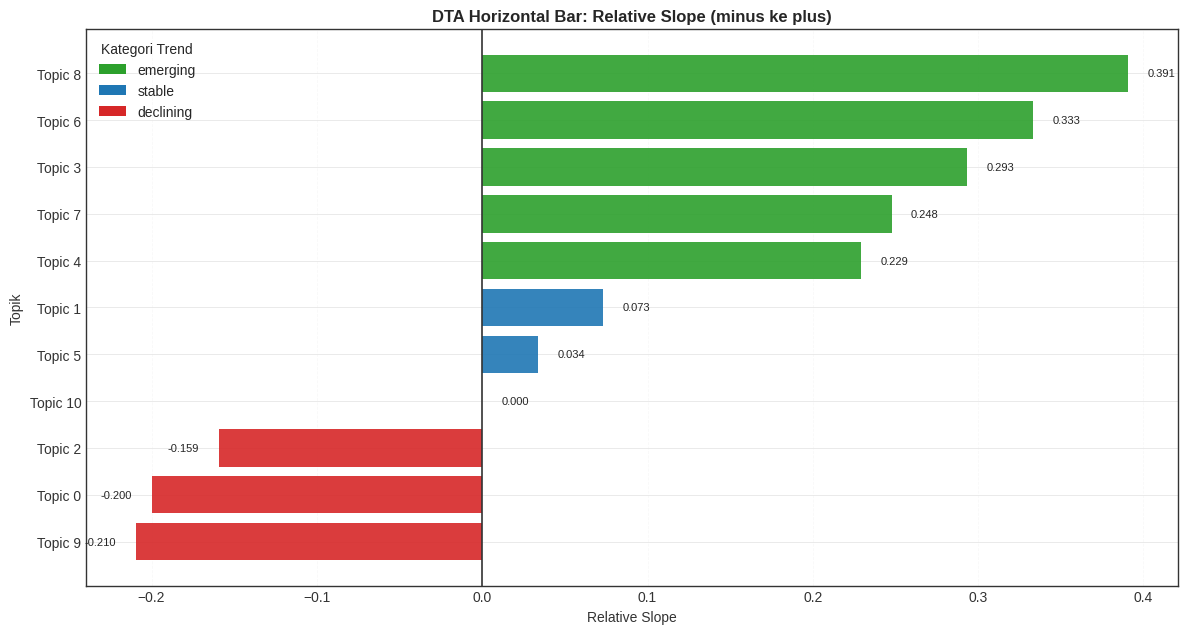

,topic_id,trend_label,relative_slope,slope,start_frequency,end_frequency,keywords_top10
0,9,declining,-2.095238e-01,-6.285714e-01,3.0,1.0,"pmks, berbasis web, banjarnegara, rancang bang..."
1,0,declining,-2.000000e-01,-1.866667e+00,14.0,1.0,"desa, berbasis web, umkm, rancang bangun, meng..."
2,2,declining,-1.593750e-01,-1.133333e+00,12.0,1.0,"penjualan, transaksi, sampah, waterfall, berba..."
3,10,stable,4.665854e-18,1.866342e-17,1.0,3.0,"analisis sentimen, negatif, naïve, naïve bayes..."
4,5,stable,3.361345e-02,1.428571e-01,7.0,2.0,"pendukung keputusan, penilaian, kriteria, simp..."
5,1,stable,7.333333e-02,7.333333e-01,7.0,6.0,"unsoed, perancangan, audit, laporan, monitorin..."
6,4,emerging,2.290909e-01,1.400000e+00,1.0,3.0,"deteksi, cnn, performa, precision, diagnosis, ..."
7,7,emerging,2.476190e-01,9.285714e-01,1.0,4.0,"klasterisasi, klasifikasi, umkm, hama, algorit..."
8,3,emerging,2.931034e-01,1.700000e+00,3.0,3.0,"performa, laravel, server, beban, throughput, ..."
9,6,emerging,3.333333e-01,1.600000e+00,1.0,7.0,"edukasi, siswa, pembelajaran, permainan, devel..."


In [15]:
# Diagram horizontal minus -> plus untuk validasi emerging/stable/declining
from matplotlib.patches import Patch

trend_path = RUN_DIR / "dta_topic_trend_classification.csv"
if not trend_path.exists():
    print(f"File DTA trend belum ditemukan: {trend_path}")
else:
    dta_trend_bar_df = pd.read_csv(trend_path)
    if dta_trend_bar_df.empty:
        print("File DTA trend kosong, tidak ada data untuk diplot.")
    else:
        dta_trend_bar_df = dta_trend_bar_df.copy()
        if "relative_slope" not in dta_trend_bar_df.columns:
            print("Kolom relative_slope tidak ditemukan di file DTA trend.")
        else:
            dta_trend_bar_df["relative_slope"] = pd.to_numeric(
                dta_trend_bar_df["relative_slope"], errors="coerce"
            ).fillna(0.0)

            if "topic_id" not in dta_trend_bar_df.columns:
                dta_trend_bar_df["topic_id"] = np.arange(1, len(dta_trend_bar_df) + 1)

            # Pastikan label trend tersedia; fallback ke threshold slope jika kolom belum ada.
            threshold = 0.03
            if "trend_label" not in dta_trend_bar_df.columns:
                dta_trend_bar_df["trend_label"] = np.where(
                    dta_trend_bar_df["relative_slope"] >= threshold,
                    "emerging",
                    np.where(
                        dta_trend_bar_df["relative_slope"] <= -threshold,
                        "declining",
                        "stable",
                    ),
                )
            else:
                dta_trend_bar_df["trend_label"] = (
                    dta_trend_bar_df["trend_label"]
                    .fillna("stable")
                    .astype(str)
                    .str.strip()
                    .str.lower()
                )

            dta_trend_bar_df = dta_trend_bar_df.sort_values("relative_slope", ascending=True).reset_index(drop=True)
            dta_trend_bar_df["topic_label"] = dta_trend_bar_df["topic_id"].apply(lambda v: f"Topic {int(v)}")

            color_map = {
                "emerging": "#2ca02c",
                "stable": "#1f77b4",
                "declining": "#d62728",
                "insufficient_data": "#7f7f7f",
            }
            bar_colors = [color_map.get(lbl, "#7f7f7f") for lbl in dta_trend_bar_df["trend_label"]]

            fig_height = max(4, 0.45 * len(dta_trend_bar_df) + 1.5)
            fig, ax = plt.subplots(figsize=(12, fig_height))
            bars = ax.barh(
                dta_trend_bar_df["topic_label"],
                dta_trend_bar_df["relative_slope"],
                color=bar_colors,
                alpha=0.9,
            )

            ax.axvline(0, color="#333333", linewidth=1.2, linestyle="-")
            ax.set_title("DTA Horizontal Bar: Relative Slope (minus ke plus)")
            ax.set_xlabel("Relative Slope")
            ax.set_ylabel("Topik")
            ax.grid(axis="x", alpha=0.25, linestyle="--")

            max_abs = float(dta_trend_bar_df["relative_slope"].abs().max() or 0.0)
            x_pad = max(max_abs * 0.03, 0.003)
            for bar, value in zip(bars, dta_trend_bar_df["relative_slope"]):
                x_pos = value + x_pad if value >= 0 else value - x_pad
                ha = "left" if value >= 0 else "right"
                ax.text(
                    x_pos,
                    bar.get_y() + bar.get_height() / 2,
                    f"{value:.3f}",
                    va="center",
                    ha=ha,
                    fontsize=8,
                )

            legend_order = ["emerging", "stable", "declining", "insufficient_data"]
            trend_set = set(dta_trend_bar_df["trend_label"].tolist())
            legend_handles = [
                Patch(facecolor=color_map[label], edgecolor="none", label=label)
                for label in legend_order
                if label in trend_set
            ]
            if legend_handles:
                ax.legend(handles=legend_handles, title="Kategori Trend", loc="best")

            plt.tight_layout()
            plt.show()

            show_cols = [
                col
                for col in [
                    "topic_id",
                    "trend_label",
                    "relative_slope",
                    "slope",
                    "start_frequency",
                    "end_frequency",
                    "keywords_top10",
                ]
                if col in dta_trend_bar_df.columns
            ]
            display(dta_trend_bar_df[show_cols])

In [16]:
# Backfill kolom outlier before/after tanpa rerun loop tuning penuh.
if "bertopic_success_payloads" not in globals() or not bertopic_success_payloads:
    print("Tidak ada bertopic_success_payloads di kernel saat ini. Jalankan ulang Cell 9 (Loop Tuning) untuk regenerasi.")
else:
    if "bertopic_results_df" not in globals() or bertopic_results_df is None or bertopic_results_df.empty:
        print("bertopic_results_df tidak tersedia/empty. Jalankan ulang Cell 9 (Loop Tuning).")
    else:
        before_after_map = {}
        for payload in bertopic_success_payloads:
            scenario = payload.get("scenario", {}) or {}
            train_result = payload.get("train_result", {}) or {}
            sid = scenario.get("scenario_id")
            if not sid:
                continue
            before_after_map[sid] = {
                "num_outliers_before_reduce": train_result.get("num_outliers_before_reduce"),
                "num_outliers_after_reduce": train_result.get("num_outliers"),
            }

        patched_df = bertopic_results_df.copy()
        patched_df["num_outliers_before_reduce"] = patched_df["scenario_id"].map(
            lambda sid: (before_after_map.get(sid) or {}).get("num_outliers_before_reduce")
        )
        patched_df["num_outliers_after_reduce"] = patched_df["scenario_id"].map(
            lambda sid: (before_after_map.get(sid) or {}).get("num_outliers_after_reduce")
        )

        # Pertahankan kompatibilitas lama: num_outliers tetap menunjuk nilai setelah reduce.
        patched_df["num_outliers"] = patched_df["num_outliers_after_reduce"].fillna(patched_df.get("num_outliers"))

        total_docs = len(bertopic_docs) if "bertopic_docs" in globals() else None
        if total_docs and total_docs > 0:
            patched_df["outlier_pct_before_reduce"] = (
                pd.to_numeric(patched_df["num_outliers_before_reduce"], errors="coerce").fillna(0.0)
                / float(total_docs)
                * 100.0
            ).round(2)
            patched_df["outlier_pct_after_reduce"] = (
                pd.to_numeric(patched_df["num_outliers_after_reduce"], errors="coerce").fillna(0.0)
                / float(total_docs)
                * 100.0
            ).round(2)

        export_path = globals().get("bertopic_results_path", RUN_DIR / "bertopic_loop_results.csv")
        patched_df.to_csv(export_path, index=False)
        bertopic_results_df = patched_df

        show_cols = [
            c
            for c in [
                "scenario_id",
                "num_outliers_before_reduce",
                "num_outliers_after_reduce",
                "num_outliers",
                "outlier_pct_before_reduce",
                "outlier_pct_after_reduce",
                "outlier_pct",
            ]
            if c in patched_df.columns
        ]
        print("BERTopic loop results diperbarui:", export_path)
        display(patched_df[show_cols].head(10))

BERTopic loop results diperbarui: /home/galih/MySkripsi/- Aplikasi/my-skripsi/fastapi/data/results/notebook_tuning_topic_models/run_20260416-132025/bertopic_loop_results.csv


,scenario_id,num_outliers_before_reduce,num_outliers_after_reduce,num_outliers,outlier_pct_before_reduce,outlier_pct_after_reduce,outlier_pct
0,bertopic_017,136,0,0,28.75,0.0,0.0
1,bertopic_006,100,0,0,21.14,0.0,0.0
2,bertopic_021,83,0,0,17.55,0.0,0.0
3,bertopic_019,131,0,0,27.70,0.0,0.0
4,bertopic_004,122,0,0,25.79,0.0,0.0
5,bertopic_007,143,0,0,30.23,0.0,0.0
6,bertopic_013,59,0,0,12.47,0.0,0.0
7,bertopic_016,137,0,0,28.96,0.0,0.0
8,bertopic_014,76,0,0,16.07,0.0,0.0
9,bertopic_011,119,0,0,25.16,0.0,0.0


## Visualisasi UMAP & HDBSCAN untuk Laporan Skripsi
Meskipun hasil \`UMAP\` dan \`HDBSCAN\` tidak disimpan dalam format \`safetensors\` pada _endpoint_ FastAPI (demi keamanan dan penghematan Storage), model yang masih aktif di dalam **Jupyter memori** kali ini masih memiliki akses terhadap matriks reduksi dan label cluster tersebut.

Cell di bawah ini akan:
1. Menampilkan _Interactive Plot_ bawaan dari BERTopic menggunakan \`plotly\` (sangat bagus untuk di-eksplorasi tapi mungkin berat).
2. Men-generate dan mengekstrak \`UMAP embeddings\` secara manual (plot statis 2D via \`matplotlib\` / \`seaborn\`) yang siap Anda _export_ (\`Save image as...\` klik kanan) dengan ukuran yang lebih ringan untuk kebutuhan laporan (_Word/PDF_).

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

if "final_bertopic" not in globals() or final_bertopic is None:
    print("final_bertopic tidak ditemukan. Pastikan Anda telah menjalankan Cell 'Pemilihan & Penyimpanan ...'.")
else:
    best_trainer = final_bertopic["trainer"]
    bt_model = best_trainer.model
    bt_topics = best_trainer.topics
    print(f"Topik terbaik menggunakan UMAP model:\n  {bt_model.umap_model}\nDan HDBSCAN:\n  {bt_model.hdbscan_model}")

    print("\n--- 1. Visualisasi Plot Bawaan Interaktif (Plotly) (DIMATIKAN SEMENTARA) ---")
    print("Plotly interaktif di-comment agar tidak error nbformat. Lewati langsung ke Matplotlib.")
    try:
        
        sample_subset = 0.2 # gunakan 20% sample
        
        
        pass
    except Exception as e:
        print(f"Gagal memproses visualisasi bawaan: {e}")

    print("\n--- 2. Visualisasi Plot Statis (Statis - Matplotlib & Seaborn) ---")
    try:
        umap_model = bt_model.umap_model
        
        print("Mengekstrak embedding...")
        
        # Ekstrak 2D embedding (UMAP proj) langsung dari attribute setelah fitting
        if hasattr(umap_model, 'embedding_'):
            umap_2d = umap_model.embedding_
        else:
            # Jika parameter low_memory dimatikan/dihidupkan seringkali atributnya berbeda, maka kita transform lagi sampel
            num_samples = min(2000, len(shared_embeddings))
            print(f"Me-reduksi sampel kembali ({num_samples} data)...")
            umap_2d = umap_model.transform(shared_embeddings[:num_samples])

        bt_topics_sliced = bt_topics[:len(umap_2d)]
        
        df_umap = pd.DataFrame(umap_2d, columns=['UMAP_1', 'UMAP_2'])
        df_umap['Topic'] = bt_topics_sliced
        
        # Buat Plot Matplotlib/Seaborn statis
        plt.figure(figsize=(10, 8))
        
        # Plot outlier
        sns.scatterplot(
            data=df_umap[df_umap['Topic'] == -1],
            x='UMAP_1', y='UMAP_2', 
            color='lightgrey', s=10, alpha=0.5, label='Outliers (-1)'
        )
        
        # Plot topik berklaster
        sns.scatterplot(
            data=df_umap[df_umap['Topic'] != -1],
            x='UMAP_1', y='UMAP_2', 
            hue='Topic', palette='tab20', s=30, alpha=0.8, legend=False
        )
        
        plt.title('Plot Reduksi Dimensionalitas UMAP dan Cluster HDBSCAN\n(Pemisahan antar Dokumen Tema)\n', fontsize=14)
        plt.xlabel('UMAP Dimension 1', fontsize=12)
        plt.ylabel('UMAP Dimension 2', fontsize=12)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Gagal memproses visualisasi statis: {e}")

Topik terbaik menggunakan UMAP model:
  UMAP(angular_rp_forest=True, metric='cosine', min_dist=0.0, n_components=10, n_jobs=1, n_neighbors=45, random_state=42, tqdm_kwds={'bar_format': '{desc}: {percentage:3.0f}%| {bar} {n_fmt}/{total_fmt} [{elapsed}]', 'desc': 'Epochs completed', 'disable': True})
Dan HDBSCAN:
  HDBSCAN(core_dist_n_jobs=1, min_cluster_size=12, min_samples=1,
        prediction_data=True)

--- 1. Visualisasi Plot Bawaan Interaktif (Plotly) (DIMATIKAN SEMENTARA) ---
Plotly interaktif di-comment agar tidak error nbformat. Lewati langsung ke Matplotlib.

--- 2. Visualisasi Plot Statis (Statis - Matplotlib & Seaborn) ---
Mengekstrak embedding...
Gagal memproses visualisasi statis: Shape of passed values is (473, 10), indices imply (473, 2)
